# **Part 3 : The international diversification strategy**

### ***3.a. Converting returns in USD***

In [87]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

#### *Preliminary task : Data Wrangling*

    1. For exchanges rates

In [88]:
# Create dataframe with conversion rate 
aud_to_usd = pd.read_csv('./data/EXUSAL.csv') # aud to usd
eur_to_usd = pd.read_csv('./data/EXUSEU.csv') # eur to usd
jpy_to_usd = pd.read_csv('./data/EXJPUS.csv') # usd to jpy
chf_to_usd = pd.read_csv('./data/EXSZUS.csv') # usd to chf
gbp_to_usd = pd.read_csv('./data/EXUSUK.csv') # gbp to usd


# Renaming the columns for convenience 
aud_to_usd = aud_to_usd.rename(columns={'EXUSAL': 'exchange_rate'})
eur_to_usd = eur_to_usd.rename(columns={'EXUSEU': 'exchange_rate'})
jpy_to_usd = jpy_to_usd.rename(columns={'EXJPUS': 'exchange_rate'})
chf_to_usd = chf_to_usd.rename(columns={'EXSZUS': 'exchange_rate'})
gbp_to_usd = gbp_to_usd.rename(columns={'EXUSUK': 'exchange_rate'})

In [89]:
# handle NaN values by linear interpolation
aud_to_usd['exchange_rate'] = aud_to_usd['exchange_rate'].interpolate(method='linear') 
eur_to_usd['exchange_rate'] = eur_to_usd['exchange_rate'].interpolate(method='linear')
jpy_to_usd['exchange_rate'] = 1/jpy_to_usd['exchange_rate'].interpolate(method='linear')
chf_to_usd['exchange_rate'] = 1/chf_to_usd['exchange_rate'].interpolate(method='linear')
gbp_to_usd['exchange_rate'] = gbp_to_usd['exchange_rate'].interpolate(method='linear')

In [90]:
# Compute the returns from the exchange rates
aud_to_usd['FX_return'] = (aud_to_usd['exchange_rate'] - aud_to_usd['exchange_rate'].shift(1)) / aud_to_usd['exchange_rate'].shift(1)
eur_to_usd['FX_return'] = (eur_to_usd['exchange_rate'] - eur_to_usd['exchange_rate'].shift(1)) / eur_to_usd['exchange_rate'].shift(1)
jpy_to_usd['FX_return'] = (jpy_to_usd['exchange_rate'] - jpy_to_usd['exchange_rate'].shift(1)) / jpy_to_usd['exchange_rate'].shift(1)
chf_to_usd['FX_return'] = (chf_to_usd['exchange_rate'] - chf_to_usd['exchange_rate'].shift(1)) / chf_to_usd['exchange_rate'].shift(1)
gbp_to_usd['FX_return'] = (gbp_to_usd['exchange_rate'] - gbp_to_usd['exchange_rate'].shift(1)) / gbp_to_usd['exchange_rate'].shift(1)


In [91]:
#drop NaN
aud_to_usd = aud_to_usd.dropna().reset_index(drop=True)
eur_to_usd = eur_to_usd.dropna().reset_index(drop=True)
jpy_to_usd = jpy_to_usd.dropna().reset_index(drop=True)
chf_to_usd = chf_to_usd.dropna().reset_index(drop=True)
gbp_to_usd = gbp_to_usd.dropna().reset_index(drop=True)


# Set the start date for all dataframes at 2002-05-01 to match japan
aud_to_usd = aud_to_usd[aud_to_usd['observation_date'] >= '2002-05-01'].reset_index(drop=True)
eur_to_usd = eur_to_usd[eur_to_usd['observation_date'] >= '2002-05-01'].reset_index(drop=True)
jpy_to_usd = jpy_to_usd[jpy_to_usd['observation_date'] >= '2002-05-01'].reset_index(drop=True)
chf_to_usd = chf_to_usd[chf_to_usd['observation_date'] >= '2002-05-01'].reset_index(drop=True)
gbp_to_usd = gbp_to_usd[gbp_to_usd['observation_date'] >= '2002-05-01'].reset_index(drop=True)

**Critical Assumption :** The observed return on 2002-05-01 is actually the return of month 2002-04 $\Rightarrow$ Need to shift the values by one month backwards and dropping the day value

In [92]:
aud_to_usd['observation_date'] = (pd.to_datetime(aud_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
eur_to_usd['observation_date'] = (pd.to_datetime(eur_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
jpy_to_usd['observation_date'] = (pd.to_datetime(jpy_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
chf_to_usd['observation_date'] = (pd.to_datetime(chf_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')
gbp_to_usd['observation_date'] = (pd.to_datetime(gbp_to_usd['observation_date']) - pd.DateOffset(months=1)).dt.strftime('%Y-%m')

# Check that all dataframes start at same date
# print(aud_to_usd.head())
# print(eur_to_usd.head())
# print(jpy_to_usd.head())
# print(chf_to_usd.head())
# print(gbp_to_usd.head())

In [93]:
# Create Exchange rates dataframe and save it to csv format 
exchange_rates = pd.DataFrame({
    'date': aud_to_usd['observation_date'],
    'Australia': aud_to_usd['exchange_rate'],
    'Britain': gbp_to_usd['exchange_rate'],
    'France': eur_to_usd['exchange_rate'],
    'Germany': eur_to_usd['exchange_rate'],
    'Japan': jpy_to_usd['exchange_rate'],
    'Switzerland': chf_to_usd['exchange_rate'],
})

exchange_rates.to_csv('./data/exchange_rates.csv', index=False)
exchange_rates.head()

,date,Australia,Britain,France,Germany,Japan,Switzerland
0,2002-04,0.5498,1.4598,0.9170,0.9170,0.007913,0.629366
1,2002-05,0.5682,1.4837,0.9561,0.9561,0.008111,0.649393
2,2002-06,0.5538,1.5565,0.9935,0.9935,0.008482,0.679440
3,2002-07,0.5413,1.5368,0.9781,0.9781,0.008404,0.667913
4,2002-08,0.5465,1.5563,0.9806,0.9806,0.008259,0.669748


In [94]:
# Create FX returns dataframe and save it to csv format 
fx_returns = pd.DataFrame({
    'date': aud_to_usd['observation_date'],
    'Australia': aud_to_usd['FX_return'],
    'Britain': gbp_to_usd['FX_return'],
    'France': eur_to_usd['FX_return'],
    'Germany': eur_to_usd['FX_return'],
    'Japan': jpy_to_usd['FX_return'],
    'Switzerland': chf_to_usd['FX_return'],
})

fx_returns.to_csv('./data/fx_returns.csv', index=False)
fx_returns.head()

,date,Australia,Britain,France,Germany,Japan,Switzerland
0,2002-04,0.027280,0.011713,0.034989,0.034989,0.034792,0.041098
1,2002-05,0.033467,0.016372,0.042639,0.042639,0.025018,0.031820
2,2002-06,-0.025343,0.049067,0.039117,0.039117,0.045729,0.046270
3,2002-07,-0.022571,-0.012657,-0.015501,-0.015501,-0.009190,-0.016965
4,2002-08,0.009607,0.012689,0.002556,0.002556,-0.017223,0.002746


    2. For country indices

In [95]:
# Load the stocks per country
world_data = pd.read_csv('./data/country_data.csv', sep=';')

australia = world_data[world_data.country == 'AUSTRALIA'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)
france = world_data[world_data.country == 'FRANCE'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)
germany = world_data[world_data.country == 'GERMANY'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)
japan = world_data[world_data.country == 'JAPAN'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)
switzerland = world_data[world_data.country == 'SWITZERLAND'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)
britain = world_data[world_data.country == 'UNITED KINGDOM'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'}).reset_index(drop=True)

# Load the stocks for the US
usa = pd.read_csv('./data/crsp_value_weighted_returns.csv', sep=';').rename(columns={'vwretx': 'monthly_price_return', 'vwretd': 'monthly_total_return'})

**Important note :** Since observations are made on the last day of each month, that means that the return observed on 2002-01-31 corresponds to the return of month 2002-01

In [96]:
# Only keep the month and the year 
australia['date'] = pd.to_datetime(australia['date']).dt.strftime('%Y-%m')
france['date'] = pd.to_datetime(france['date']).dt.strftime('%Y-%m')
japan['date'] = pd.to_datetime(japan['date']).dt.strftime('%Y-%m')
germany['date'] = pd.to_datetime(germany['date']).dt.strftime('%Y-%m')
switzerland['date'] = pd.to_datetime(switzerland['date']).dt.strftime('%Y-%m')
usa['date'] = pd.to_datetime(usa['date']).dt.strftime('%Y-%m')
britain['date'] = pd.to_datetime(britain['date']).dt.strftime('%Y-%m')

***Converting country indices monthly returns in USD***

In order to compute returns in USD, we use the formula :  $R_{USD} = (1+R_{foreign})\cdot(1+R_{FX})-1$  
Where $R_{USD}$ is the corresponding return in USD, $R_{foreign}$ is the monthly return in foreign currency, and $R_{FX}$ the return on the exchange rate of foreign currency in dollar units  
  
  
Furthermore, we assume that we only study the monthly total return, ie. the monthly returns computed accounting for dividends



In [97]:
# Compute returns in USD

## Australia
australia = australia.merge(aud_to_usd, left_on='date', right_on='observation_date')
australia['monthly_total_return_USD'] = (1+australia['monthly_total_return'])*(1+australia['FX_return'])-1
#australia['monthly_price_return_USD'] = (1+australia['monthly_price_return'])*(1+australia['FX_return'])-1
australia = australia.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
australia

,date,monthly_total_return_USD
0,2002-04,0.012587
1,2002-05,0.033256
2,2002-06,-0.051421
3,2002-07,-0.059533
4,2002-08,0.025970
...,...,...
267,2024-07,0.035730
268,2024-08,0.021983
269,2024-09,0.022941
270,2024-10,-0.037250


In [98]:
## France
france = france.merge(eur_to_usd, left_on='date', right_on='observation_date')
france['monthly_total_return_USD'] = (1+france['monthly_total_return'])*(1+france['FX_return'])-1
#france['monthly_price_return_USD'] = (1+france['monthly_price_return'])*(1+france['FX_return'])-1
france = france.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
france

,date,monthly_total_return_USD
0,2002-04,-0.010538
1,2002-05,0.013428
2,2002-06,-0.044850
3,2002-07,-0.117957
4,2002-08,-0.002077
...,...,...
267,2024-07,0.018647
268,2024-08,0.025529
269,2024-09,-0.010247
270,2024-10,-0.075214


In [99]:
## Germany
germany = germany.merge(eur_to_usd, left_on='date', right_on='observation_date')
germany['monthly_total_return_USD'] = (1+germany['monthly_total_return'])*(1+germany['FX_return'])-1
#germany['monthly_price_return_USD'] = (1+germany['monthly_price_return'])*(1+germany['FX_return'])-1
germany = germany.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
germany

,date,monthly_total_return_USD
0,2002-04,-0.011617
1,2002-05,0.015840
2,2002-06,-0.032251
3,2002-07,-0.122706
4,2002-08,-0.000348
...,...,...
267,2024-07,0.019748
268,2024-08,0.025336
269,2024-09,0.007013
270,2024-10,-0.045202


In [100]:
japan = japan.merge(jpy_to_usd, left_on='date', right_on='observation_date')
japan['monthly_total_return_USD'] = (1+japan['monthly_total_return'])*(1+japan['FX_return'])-1
#japan['monthly_price_return_USD'] = (1+japan['monthly_price_return'])*(1+japan['FX_return'])-1
japan = japan.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
japan

,date,monthly_total_return_USD
0,2002-04,0.056094
1,2002-05,0.061906
2,2002-06,-0.041866
3,2002-07,-0.066380
4,2002-08,-0.041213
...,...,...
267,2024-07,0.072474
268,2024-08,-0.001815
269,2024-09,-0.059865
270,2024-10,-0.008310


In [101]:
switzerland = switzerland.merge(chf_to_usd, left_on='date', right_on='observation_date')
switzerland['monthly_total_return_USD'] = (1+switzerland['monthly_total_return'])*(1+switzerland['FX_return'])-1
#switzerland['monthly_price_return_USD'] = (1+switzerland['monthly_price_return'])*(1+switzerland['FX_return'])-1
switzerland = switzerland.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
switzerland

,date,monthly_total_return_USD
0,2002-04,0.036820
1,2002-05,0.034877
2,2002-06,-0.039197
3,2002-07,-0.147091
4,2002-08,0.007842
...,...,...
267,2024-07,0.050481
268,2024-08,0.017400
269,2024-09,-0.027682
270,2024-10,-0.052857


In [102]:
britain = britain.merge(gbp_to_usd, left_on='date', right_on='observation_date')
britain['monthly_total_return_USD'] = (1+britain['monthly_total_return'])*(1+britain['FX_return'])-1
#britain['monthly_price_return_USD'] = (1+britain['monthly_price_return'])*(1+britain['FX_return'])-1
britain = britain.drop(columns=['observation_date', 'exchange_rate', 'FX_return', 'currency', 'monthly_total_return', 'monthly_price_return'])
britain

,date,monthly_total_return_USD
0,2002-04,-0.001806
1,2002-05,0.004702
2,2002-06,-0.037508
3,2002-07,-0.101053
4,2002-08,0.015599
...,...,...
267,2024-07,0.039456
268,2024-08,0.029770
269,2024-09,-0.030240
270,2024-10,-0.040088


In [103]:
usa = usa.iloc[3:-1].drop(columns='monthly_price_return').reset_index(drop=True)
usa

,date,monthly_total_return
0,2002-04,-0.049600
1,2002-05,-0.010510
2,2002-06,-0.070259
3,2002-07,-0.081125
4,2002-08,0.007949
...,...,...
267,2024-07,0.019878
268,2024-08,0.021572
269,2024-09,0.020969
270,2024-10,-0.008298


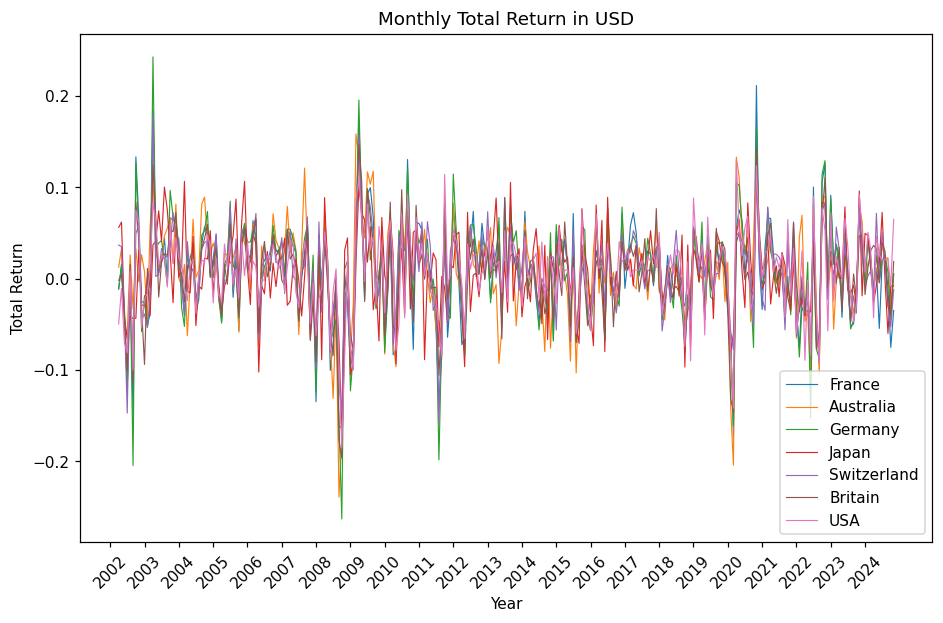

In [104]:
# Plot returns in USD
plt.figure(figsize=(10,6))
plt.plot(pd.to_datetime(france['date']), france['monthly_total_return_USD'], label='France', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(australia['date']), australia['monthly_total_return_USD'], label='Australia', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(germany['date']), germany['monthly_total_return_USD'], label='Germany', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(japan['date']), japan['monthly_total_return_USD'], label='Japan', linestyle='-', linewidth=0.75)
plt.plot( pd.to_datetime(switzerland['date']), switzerland['monthly_total_return_USD'], label='Switzerland', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(britain['date']), britain['monthly_total_return_USD'], label='Britain', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(usa['date']), usa['monthly_total_return'], label='USA', linestyle='-', linewidth=0.75)  # Added USA to the plot
years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()
plt.title('Monthly Total Return in USD')
plt.xlabel('Year')
plt.ylabel('Total Return')
plt.show()


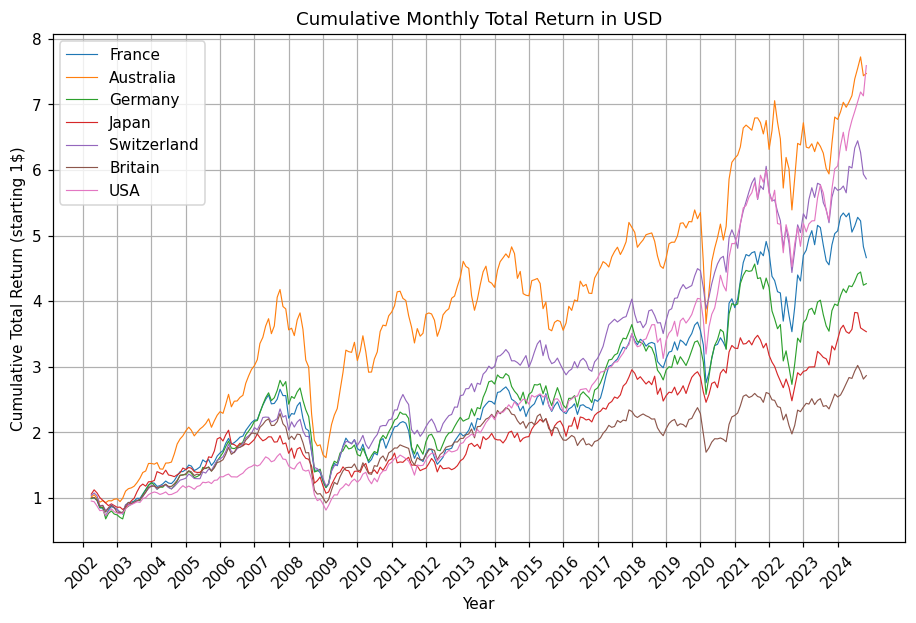

In [105]:
plt.figure(figsize=(10,6))
plt.plot(pd.to_datetime(france['date']), (1 + france['monthly_total_return_USD']).cumprod(), label='France', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + australia['monthly_total_return_USD']).cumprod(), label='Australia', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + germany['monthly_total_return_USD']).cumprod(), label='Germany', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + japan['monthly_total_return_USD']).cumprod(), label='Japan', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + switzerland['monthly_total_return_USD']).cumprod(), label='Switzerland', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + britain['monthly_total_return_USD']).cumprod(), label='Britain', linestyle='-', linewidth=0.75)
plt.plot(pd.to_datetime(france['date']), (1 + usa['monthly_total_return']).cumprod(), label='USA', linestyle='-', linewidth=0.75)  # Added USA to the plot
years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()
plt.title('Cumulative Monthly Total Return in USD')
plt.xlabel('Year')
plt.ylabel('Cumulative Total Return (starting 1$)')
plt.grid()
plt.show()


In [106]:
usd_returns = pd.DataFrame({
    'date': usa['date'],
    'France': france['monthly_total_return_USD'],
    'Australia': australia['monthly_total_return_USD'],
    'Germany': germany['monthly_total_return_USD'],
    'Japan': japan['monthly_total_return_USD'],
    'Switzerland': switzerland['monthly_total_return_USD'],
    'Britain': britain['monthly_total_return_USD'],
    'USA': usa['monthly_total_return']
})

usd_returns.to_csv('./data/USD_monthly_returns.csv', index=False)
usd_returns

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,2002-04,-0.010538,0.012587,-0.011617,0.056094,0.036820,-0.001806,-0.049600
1,2002-05,0.013428,0.033256,0.015840,0.061906,0.034877,0.004702,-0.010510
2,2002-06,-0.044850,-0.051421,-0.032251,-0.041866,-0.039197,-0.037508,-0.070259
3,2002-07,-0.117957,-0.059533,-0.122706,-0.066380,-0.147091,-0.101053,-0.081125
4,2002-08,-0.002077,0.025970,-0.000348,-0.041213,0.007842,0.015599,0.007949
...,...,...,...,...,...,...,...,...
267,2024-07,0.018647,0.035730,0.019748,0.072474,0.050481,0.039456,0.019878
268,2024-08,0.025529,0.021983,0.025336,-0.001815,0.017400,0.029770,0.021572
269,2024-09,-0.010247,0.022941,0.007013,-0.059865,-0.027682,-0.030240,0.020969
270,2024-10,-0.075214,-0.037250,-0.045202,-0.008310,-0.052857,-0.040088,-0.008298


### B. Currency hedged 

In [107]:
# Load the risk free rate and configure dates
r_f = pd.read_csv('./data/tbill.csv', sep=';').rename(columns={'mcaldt':'date', 'tmytm':'rate'})
r_f['rate'] = r_f['rate']/100
r_f['date'] = pd.to_datetime(r_f['date']).dt.strftime('%Y-%m')
r_f = r_f.iloc[3:].reset_index(drop=True)
r_f

,date,rate
0,2002-04,0.017528
1,2002-05,0.016895
2,2002-06,0.016666
3,2002-07,0.016997
4,2002-08,0.016565
...,...,...
268,2024-08,0.052564
269,2024-09,0.045916
270,2024-10,0.045024
271,2024-11,0.041699


In [108]:
# Load the 3 month interbank rates 
aud_rate = pd.read_csv('./data/AUSTRALIA.csv')
eur_rate = pd.read_csv('./data/EUROPE.csv')
jpy_rate = pd.read_csv('./data/JAPAN.csv')
chf_rate = pd.read_csv('./data/SWITZERLAND.csv')
gbp_rate = pd.read_csv('./data/GREATBRITAIN.csv')
usd_rate = pd.read_csv('./data/USA.csv')

aud_rate = aud_rate.rename(columns={'IR3TIB01AUM156N':'borrowing_rate'}) 
eur_rate = eur_rate.rename(columns={'IR3TIB01EZM156N':'borrowing_rate'})
jpy_rate = jpy_rate.rename(columns={'IR3TIB01JPM156N':'borrowing_rate'})
chf_rate = chf_rate.rename(columns={'IR3TIB01CHM156N':'borrowing_rate'})
gbp_rate = gbp_rate.rename(columns={'IR3TIB01GBM156N':'borrowing_rate'})
usd_rate = usd_rate.rename(columns={'IR3TIB01USM156N':'borrowing_rate'})

aud_rate['observation_date'] = pd.to_datetime(aud_rate['observation_date']) - pd.DateOffset(months=1)
aud_rate['observation_date'] = aud_rate['observation_date'].dt.strftime('%Y-%m')
eur_rate['observation_date'] = pd.to_datetime(eur_rate['observation_date']) - pd.DateOffset(months=1)
eur_rate['observation_date'] = eur_rate['observation_date'].dt.strftime('%Y-%m')
jpy_rate['observation_date'] = pd.to_datetime(jpy_rate['observation_date']) - pd.DateOffset(months=1)
jpy_rate['observation_date'] = jpy_rate['observation_date'].dt.strftime('%Y-%m')
chf_rate['observation_date'] = pd.to_datetime(chf_rate['observation_date']) - pd.DateOffset(months=1)
chf_rate['observation_date'] = chf_rate['observation_date'].dt.strftime('%Y-%m')
gbp_rate['observation_date'] = pd.to_datetime(gbp_rate['observation_date']) - pd.DateOffset(months=1)
gbp_rate['observation_date'] = gbp_rate['observation_date'].dt.strftime('%Y-%m')
usd_rate['observation_date'] = pd.to_datetime(usd_rate['observation_date']) - pd.DateOffset(months=1)
usd_rate['observation_date'] = usd_rate['observation_date'].dt.strftime('%Y-%m')

aud_rate['borrowing_rate'] = aud_rate['borrowing_rate'].interpolate(method='linear')
eur_rate['borrowing_rate'] = eur_rate['borrowing_rate'].interpolate(method='linear')
jpy_rate['borrowing_rate'] = jpy_rate['borrowing_rate'].interpolate(method='linear')
chf_rate['borrowing_rate'] = chf_rate['borrowing_rate'].interpolate(method='linear')
gbp_rate['borrowing_rate'] = gbp_rate['borrowing_rate'].interpolate(method='linear')
usd_rate['borrowing_rate'] = usd_rate['borrowing_rate'].interpolate(method='linear')

aud_rate['borrowing_rate'] = aud_rate['borrowing_rate'] / 100
eur_rate['borrowing_rate'] = eur_rate['borrowing_rate'] / 100
jpy_rate['borrowing_rate'] = jpy_rate['borrowing_rate'] / 100
chf_rate['borrowing_rate'] = chf_rate['borrowing_rate'] / 100
gbp_rate['borrowing_rate'] = gbp_rate['borrowing_rate'] / 100
usd_rate['borrowing_rate'] = usd_rate['borrowing_rate'] / 100

aud_rate = aud_rate[aud_rate['observation_date'] >= '2002-04'].reset_index(drop=True)
eur_rate = eur_rate[eur_rate['observation_date'] >= '2002-04'].reset_index(drop=True)
jpy_rate = jpy_rate[jpy_rate['observation_date'] >= '2002-04'].reset_index(drop=True)
chf_rate = chf_rate[chf_rate['observation_date'] >= '2002-04'].reset_index(drop=True)
gbp_rate = gbp_rate[gbp_rate['observation_date'] >= '2002-04'].reset_index(drop=True)
usd_rate = usd_rate[usd_rate['observation_date'] >= '2002-04'].reset_index(drop=True)

In [109]:
# Compute excess returns
excess_ret = pd.DataFrame()
excess_ret['date'] = aud_rate['observation_date']

excess_ret['France'] = (eur_to_usd['exchange_rate'].shift(-1)/eur_to_usd['exchange_rate'])*(1+eur_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['Australia'] = (aud_to_usd['exchange_rate'].shift(-1)/aud_to_usd['exchange_rate'])*(1+aud_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['Germany'] = (eur_to_usd['exchange_rate'].shift(-1)/eur_to_usd['exchange_rate'])*(1+eur_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['Japan'] = (jpy_to_usd['exchange_rate'].shift(-1)/jpy_to_usd['exchange_rate'])*(1+jpy_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['Switzerland'] = (chf_to_usd['exchange_rate'].shift(-1)/chf_to_usd['exchange_rate'])*(1+chf_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['Britain'] = (gbp_to_usd['exchange_rate'].shift(-1)/gbp_to_usd['exchange_rate'])*(1+gbp_rate['borrowing_rate'])-(1+usd_rate['borrowing_rate'])
excess_ret['USA'] = 0
excess_ret = excess_ret.dropna()
excess_ret['date'] = pd.to_datetime(excess_ret['date']).dt.strftime('%m-%Y')

excess_ret

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,04-2002,0.060589,0.065287,0.060589,0.007638,0.025625,0.040389,0
1,05-2002,0.057012,0.005972,0.057012,0.028570,0.040198,0.074792,0
2,06-2002,0.000171,0.008205,0.000171,-0.026199,-0.025005,0.009535,0
3,07-2002,0.018861,0.042383,0.018861,-0.033835,-0.007852,0.035760,0
4,08-2002,0.016134,0.038703,0.016134,-0.039655,-0.011537,0.023089,0
...,...,...,...,...,...,...,...,...
266,06-2024,0.000285,-0.010848,0.000285,0.025631,-0.001296,0.003924,0
267,07-2024,-0.007831,0.010159,-0.007831,-0.025436,-0.027771,0.020106,0
268,08-2024,-0.033731,-0.015197,-0.033731,-0.092438,-0.054917,-0.014159,0
269,09-2024,-0.040479,-0.028904,-0.040479,-0.068566,-0.059704,-0.023195,0


In [110]:
# Calculate the difference between all columns except 'date'
hedged_returns = usd_returns.drop(columns=['date']).subtract(excess_ret.drop(columns=['date']))
hedged_returns['date'] = usd_returns.date
hedged_returns = hedged_returns[['date', 'France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']]
hedged_returns = hedged_returns.dropna()
hedged_returns.to_csv('./data/hedged_returns.csv', index=False)

hedged_returns

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,2002-04,-0.071127,-0.052699,-0.072206,0.048456,0.011195,-0.042195,-0.049600
1,2002-05,-0.043584,0.027284,-0.041172,0.033336,-0.005320,-0.070090,-0.010510
2,2002-06,-0.045020,-0.059626,-0.032422,-0.015667,-0.014192,-0.047043,-0.070259
3,2002-07,-0.136817,-0.101916,-0.141567,-0.032545,-0.139239,-0.136813,-0.081125
4,2002-08,-0.018210,-0.012733,-0.016481,-0.001558,0.019380,-0.007490,0.007949
...,...,...,...,...,...,...,...,...
266,2024-06,-0.054761,0.024602,-0.003400,-0.008334,-0.002760,-0.008618,0.026073
267,2024-07,0.026478,0.025571,0.027579,0.097910,0.078252,0.019350,0.019878
268,2024-08,0.059260,0.037179,0.059067,0.090624,0.072317,0.043929,0.021572
269,2024-09,0.030233,0.051845,0.047493,0.008701,0.032022,-0.007045,0.020969


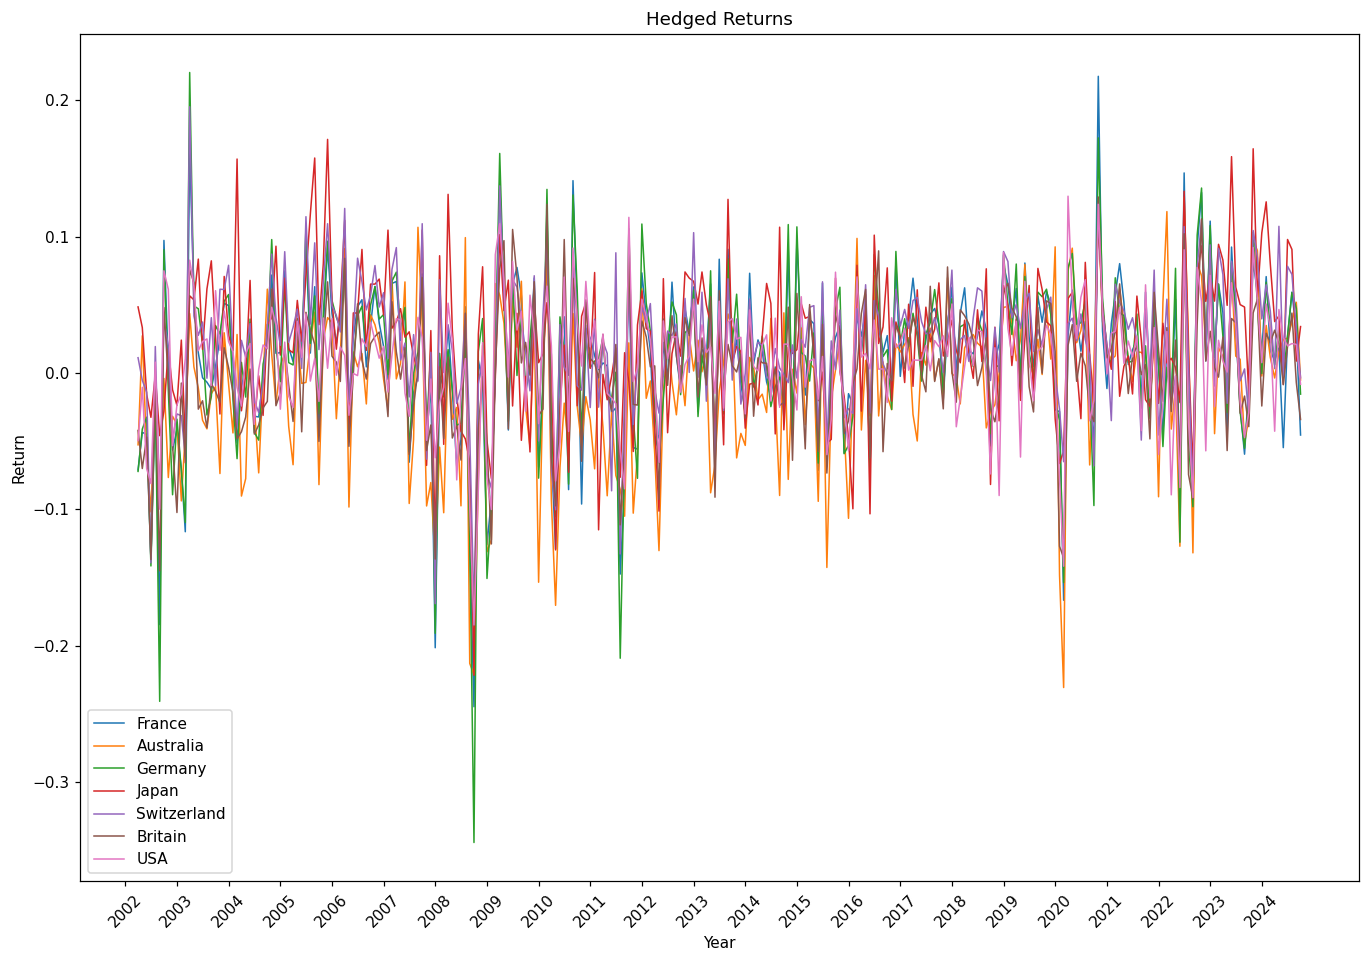

In [111]:
# US remains USD returns as computed earlier
fig, ax = plt.subplots(figsize=(15, 10))  # Adjust figure size to be slightly smaller

# Convert 'date' column to datetime format for better plotting
hedged_returns['date'] = pd.to_datetime(hedged_returns['date'])

# Plotting each country's returns
for country in ['France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']:
    ax.plot(hedged_returns['date'], hedged_returns[country], linestyle='-', linewidth=1, label=country)

# Setting x-axis ticks to show unique years and inclining dates by 45 degrees
years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('Hedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Return')
ax.legend()
plt.show()


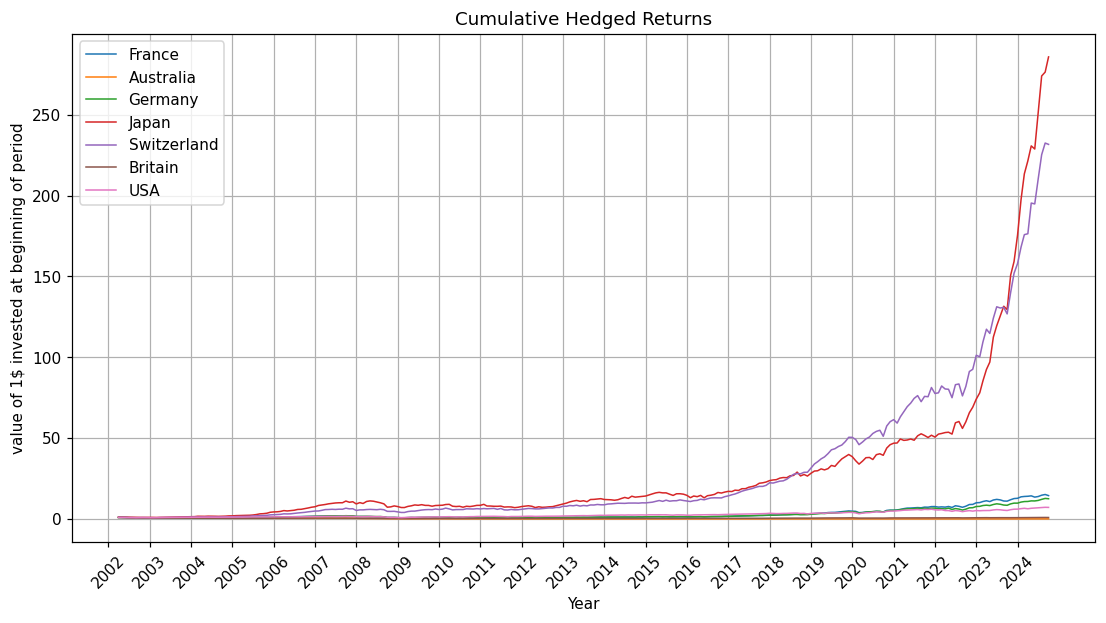

In [112]:
hedged_returns_cumulative = (1 + hedged_returns.drop(columns=['date'])).cumprod()
hedged_returns_cumulative['date'] = hedged_returns['date']

fig, ax = plt.subplots(figsize=(12, 6))  

for country in ['France', 'Australia', 'Germany', 'Japan', 'Switzerland', 'Britain', 'USA']:
    ax.plot(hedged_returns_cumulative['date'], hedged_returns_cumulative[country], linestyle='-', linewidth=1, label=country)

years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('Cumulative Hedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('value of 1$ invested at beginning of period')
ax.legend()
plt.grid()
plt.show()

### **C. International Diversification :** We consider 3 different approaches for a US investor to diversify internationally

##### ***1. Portfolio of equally weighted indices***

    Using currency hedged returns

In [113]:
hedged_returns

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA
0,2002-04-01,-0.071127,-0.052699,-0.072206,0.048456,0.011195,-0.042195,-0.049600
1,2002-05-01,-0.043584,0.027284,-0.041172,0.033336,-0.005320,-0.070090,-0.010510
2,2002-06-01,-0.045020,-0.059626,-0.032422,-0.015667,-0.014192,-0.047043,-0.070259
3,2002-07-01,-0.136817,-0.101916,-0.141567,-0.032545,-0.139239,-0.136813,-0.081125
4,2002-08-01,-0.018210,-0.012733,-0.016481,-0.001558,0.019380,-0.007490,0.007949
...,...,...,...,...,...,...,...,...
266,2024-06-01,-0.054761,0.024602,-0.003400,-0.008334,-0.002760,-0.008618,0.026073
267,2024-07-01,0.026478,0.025571,0.027579,0.097910,0.078252,0.019350,0.019878
268,2024-08-01,0.059260,0.037179,0.059067,0.090624,0.072317,0.043929,0.021572
269,2024-09-01,0.030233,0.051845,0.047493,0.008701,0.032022,-0.007045,0.020969


In [114]:
# hedged returns
equally_weighted_hedged = pd.DataFrame()
equally_weighted_hedged['date'] = hedged_returns['date']
equally_weighted_hedged['returns'] = hedged_returns.drop(columns='date').sum(axis=1)/7 #annualized returns
equally_weighted_hedged['excess_returns'] = equally_weighted_hedged['returns']- r_f['rate']/12

display(equally_weighted_hedged.excess_returns.describe())

sharpe_ratio_equally_hedged = (equally_weighted_hedged['excess_returns'].mean() / equally_weighted_hedged['excess_returns'].std())*np.sqrt(12) #assuming excess returns
print("Sharpe Ratio of Equally Weighted Hedged:", sharpe_ratio_equally_hedged)

count    271.000000
mean       0.008346
std        0.046636
min       -0.225545
25%       -0.011956
50%        0.015018
75%        0.036561
max        0.142324
Name: excess_returns, dtype: float64

Sharpe Ratio of Equally Weighted Hedged: 0.6199372222955004


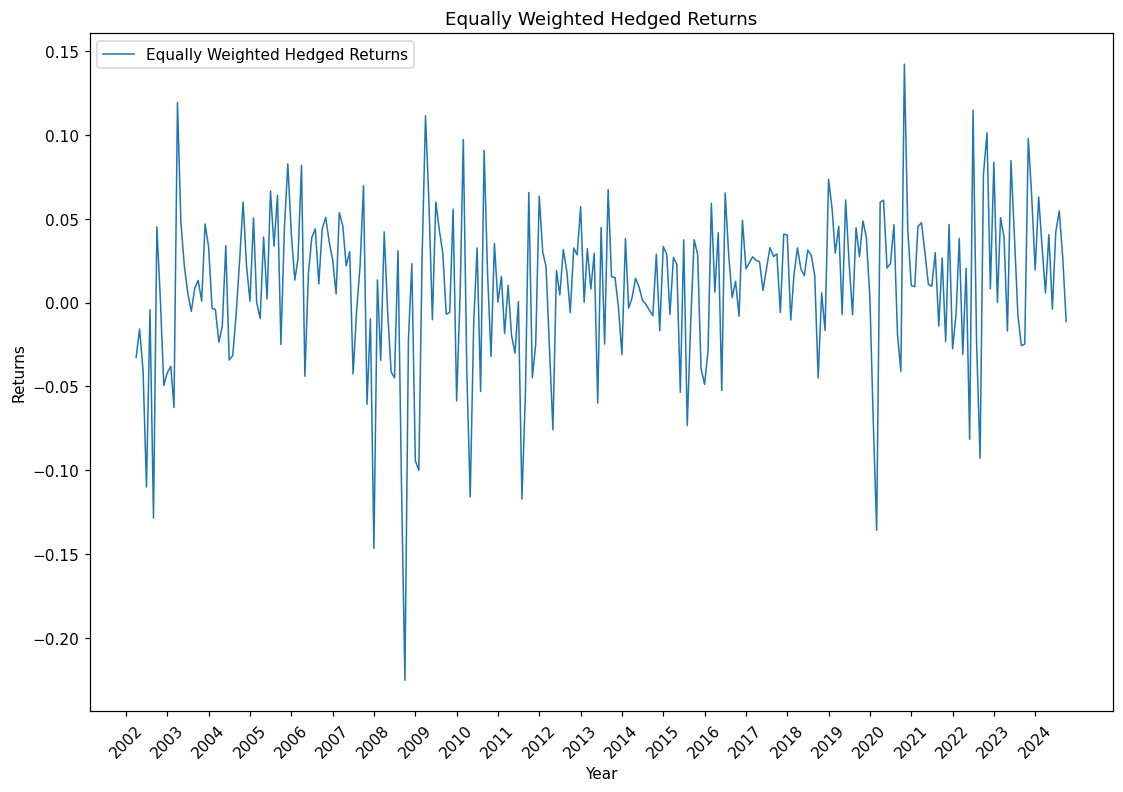

In [115]:
fig, ax = plt.subplots(figsize=(12, 8))  

ax.plot(equally_weighted_hedged['date'], equally_weighted_hedged['returns'], linestyle='-', linewidth=1, label='Equally Weighted Hedged Returns')

ax.set_xticks(pd.date_range(start=equally_weighted_hedged['date'].min(), end=equally_weighted_hedged['date'].max(), freq='YS'))
years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('Equally Weighted Hedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

    Using USD returns (unhedged for currency)

In [116]:
# unhedged returns
equally_weighted_unhedged = pd.DataFrame()
equally_weighted_unhedged['date'] = usd_returns['date']
equally_weighted_unhedged['returns'] = usd_returns.drop(columns='date').sum(axis=1)/7
equally_weighted_unhedged['excess_returns'] = equally_weighted_unhedged['returns'] - r_f['rate']/12 #since r_f are annual returns


display(equally_weighted_unhedged.returns.describe())

sharpe_ratio_equally_unhedged = (equally_weighted_unhedged['excess_returns'].mean() / equally_weighted_unhedged['excess_returns'].std())*np.sqrt(12) #assuning excess returns
print("Sharpe Ratio of Equally Weighted Unhedged:", sharpe_ratio_equally_unhedged)


count    272.000000
mean       0.007119
std        0.044003
min       -0.186449
25%       -0.015139
50%        0.010651
75%        0.034225
max        0.145339
Name: returns, dtype: float64

Sharpe Ratio of Equally Weighted Unhedged: 0.4628975972099382


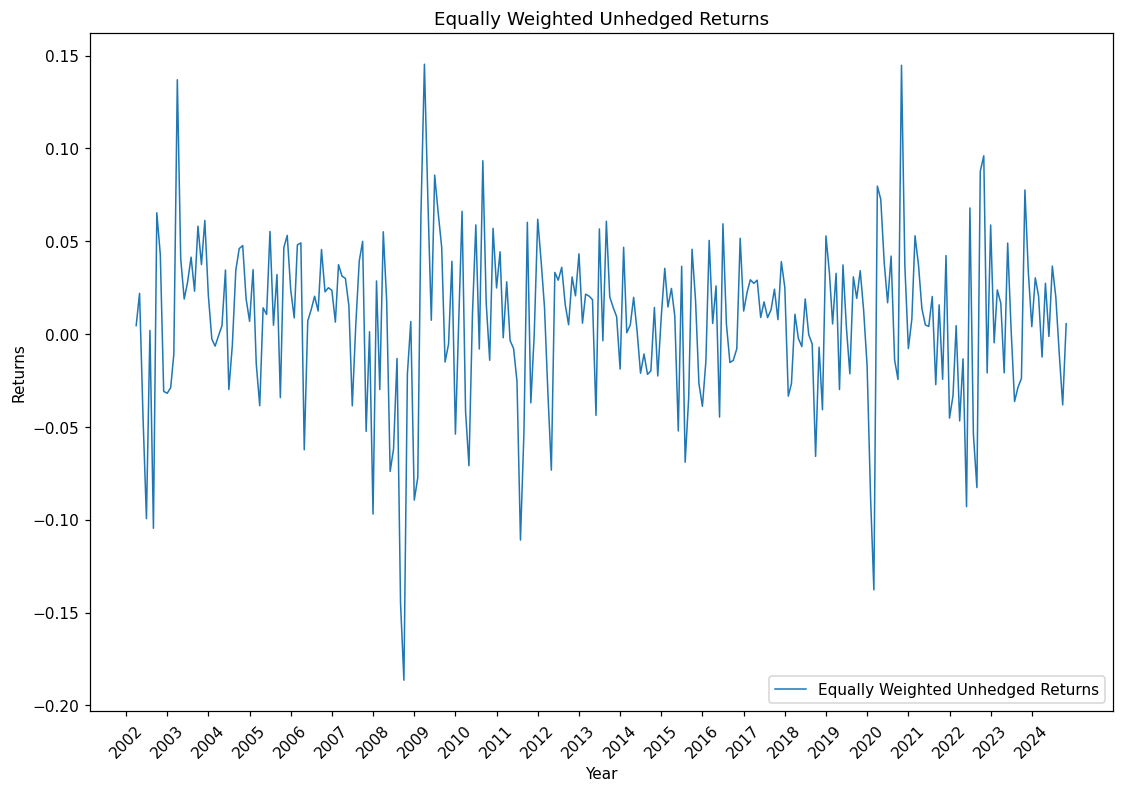

In [117]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
equally_weighted_unhedged['date'] = pd.to_datetime(equally_weighted_unhedged['date'])
ax.plot(equally_weighted_unhedged['date'], equally_weighted_unhedged['returns'], linestyle='-', linewidth=1, label='Equally Weighted Unhedged Returns')

years = [pd.to_datetime(str(year)) for year in range(2002, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('Equally Weighted Unhedged Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

#### ***2. Risk parity strategy***

    Using currency hedged returns

In [118]:
# Hedged returns 
volatilities = hedged_returns.drop(columns='date').rolling(window=60).std().shift(1) #avoid look ahead bias
volatilities['date'] = hedged_returns['date'].dt.strftime('%Y-%m')
hedged_returns['date'] = hedged_returns['date'].dt.strftime('%Y-%m')
volatilities = volatilities.dropna()

# Compute risk_parity weights given by inverse of volatility
hedged_risk_parity = 1/volatilities.drop(columns='date')
hedged_risk_parity = hedged_risk_parity.div(hedged_risk_parity.sum(axis=1), axis=0) #normalize weights vector
hedged_risk_parity['date'] = volatilities.date
hedged_risk_parity['return'] = (hedged_risk_parity.drop(columns='date')*hedged_returns[hedged_returns['date'].astype(str).isin(hedged_risk_parity['date'].astype(str))]\
                                .drop(columns='date')).sum(axis=1)
hedged_risk_parity['excess_returns'] = hedged_risk_parity['return'] - r_f[r_f['date'].astype(str).isin(hedged_risk_parity['date'].astype(str))]['rate'].values/12

#display resulting deataframe
hedged_risk_parity = hedged_risk_parity.reset_index(drop=True)
hedged_risk_parity


,France,Australia,Germany,Japan,Switzerland,Britain,USA,date,return,excess_returns
0,0.121689,0.153501,0.105335,0.139056,0.131617,0.151437,0.197365,2007-04,0.042811,0.038849
1,0.122254,0.153710,0.105471,0.138410,0.129633,0.151008,0.199514,2007-05,0.022214,0.018302
2,0.122726,0.153790,0.105572,0.137780,0.129397,0.152738,0.197997,2007-06,0.027439,0.023663
3,0.122343,0.149998,0.104781,0.137691,0.128881,0.151885,0.204420,2007-07,-0.042091,-0.046346
4,0.122589,0.144076,0.104258,0.133971,0.134477,0.154658,0.205971,2007-08,-0.004694,-0.008154
...,...,...,...,...,...,...,...,...,...,...
206,0.132173,0.118859,0.130108,0.151813,0.160893,0.159561,0.146594,2024-06,-0.004018,-0.008486
207,0.131026,0.119618,0.130418,0.150677,0.160399,0.160282,0.147580,2024-07,0.043464,0.039000
208,0.131328,0.119873,0.130715,0.149590,0.159863,0.160742,0.147889,2024-08,0.055329,0.050948
209,0.131166,0.119939,0.130612,0.149776,0.159065,0.160966,0.148477,2024-09,0.024763,0.020937


In [119]:
display(hedged_risk_parity['excess_returns'].describe())
sharpe_ratio_hedged_div = (hedged_risk_parity['excess_returns'].mean() / hedged_risk_parity['return'].std())*np.sqrt(12) 
print("Sharpe Ratio of Hedged Risk Parity:", sharpe_ratio_hedged_div)

count    211.000000
mean       0.008650
std        0.046923
min       -0.220971
25%       -0.013853
50%        0.017012
75%        0.037150
max        0.142176
Name: excess_returns, dtype: float64

Sharpe Ratio of Hedged Risk Parity: 0.6356870948014519


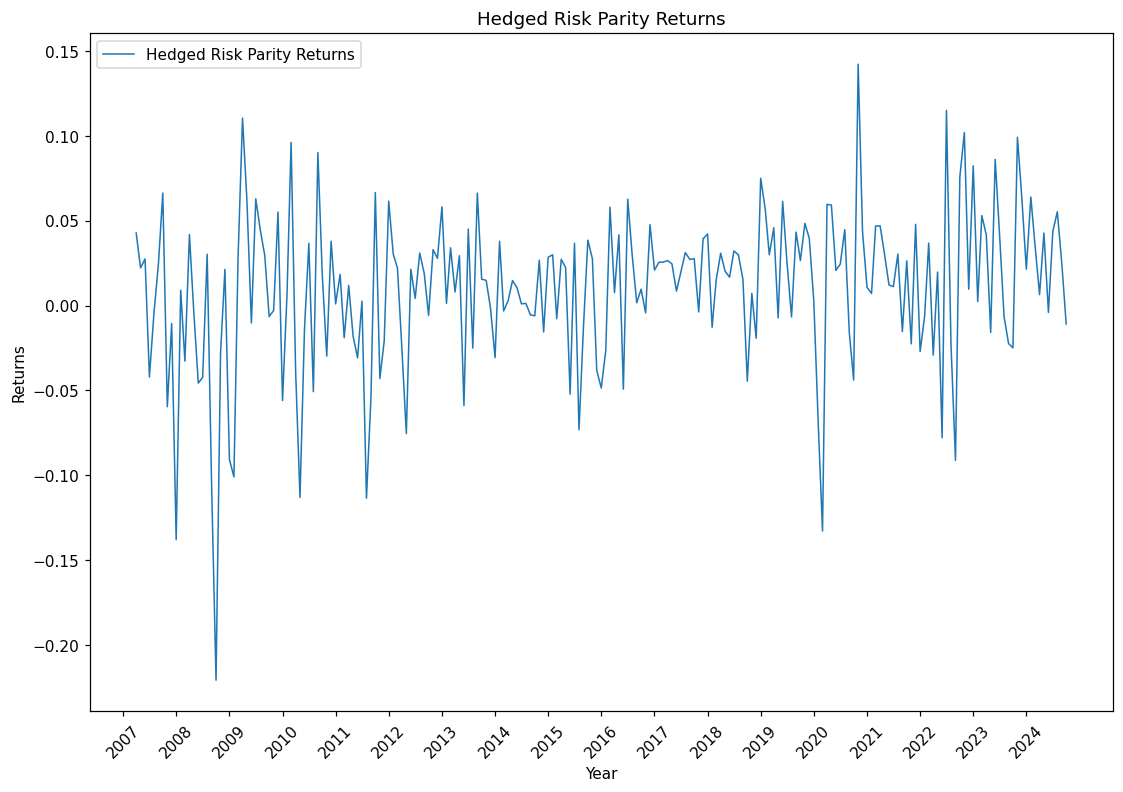

In [120]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
hedged_risk_parity['date'] = pd.to_datetime(hedged_risk_parity['date'])
ax.plot(hedged_risk_parity['date'], hedged_risk_parity['return'], linestyle='-', linewidth=1, label='Hedged Risk Parity Returns')

years = [pd.to_datetime(str(year)) for year in range(2007, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('Hedged Risk Parity Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

    Unhedged USD returns

In [121]:
# Unhedged Risk parity 
volatilities = usd_returns.drop(columns='date').rolling(window=60).std().shift(1) #avoid look ahead bias
#usd_returns['date'] = usd_returns['date'].dt.strftime('%Y-%m')
volatilities['date'] = usd_returns.date
volatilities = volatilities.dropna()

unhedged_risk_parity = 1/volatilities.drop(columns='date')
unhedged_risk_parity = unhedged_risk_parity.div(unhedged_risk_parity.sum(axis=1), axis=0)
unhedged_risk_parity['date'] = volatilities.date

unhedged_risk_parity['return'] = (unhedged_risk_parity.drop(columns='date')*usd_returns[usd_returns['date'].isin(unhedged_risk_parity['date'])].drop(columns='date')).sum(axis=1)
unhedged_risk_parity['excess_returns'] = unhedged_risk_parity['return'] - r_f[r_f['date'].astype(str).isin(unhedged_risk_parity['date'].astype(str))]['rate'].values/12
unhedged_risk_parity = unhedged_risk_parity.reset_index(drop=True)
unhedged_risk_parity

,France,Australia,Germany,Japan,Switzerland,Britain,USA,date,return,excess_returns
0,0.125573,0.161570,0.105757,0.143876,0.136415,0.148333,0.178476,2007-04,0.030036,0.026074
1,0.125115,0.161166,0.105315,0.143950,0.135555,0.148050,0.180849,2007-05,0.030247,0.026335
2,0.124926,0.160521,0.105108,0.145621,0.135689,0.147939,0.180196,2007-06,0.013669,0.009892
3,0.124047,0.162225,0.103652,0.144491,0.134413,0.146914,0.184257,2007-07,-0.038338,-0.042592
4,0.124363,0.154817,0.103025,0.141985,0.142856,0.147371,0.185582,2007-08,0.005084,0.001624
...,...,...,...,...,...,...,...,...,...,...
207,0.124078,0.124363,0.121258,0.172344,0.164897,0.153532,0.139528,2024-07,0.038798,0.034334
208,0.124720,0.124717,0.121983,0.170245,0.164469,0.153714,0.140152,2024-08,0.019168,0.014788
209,0.124442,0.124438,0.121791,0.171634,0.164264,0.153302,0.140129,2024-09,-0.014086,-0.017912
210,0.124736,0.124647,0.122239,0.170137,0.163724,0.154145,0.140373,2024-10,-0.036962,-0.040714


In [122]:
display(unhedged_risk_parity['return'].describe())
sharpe_ratio_unhedged_div = (unhedged_risk_parity['excess_returns'].mean() / unhedged_risk_parity['return'].std())*np.sqrt(12)
print("Sharpe Ratio of Unhedged Risk Parity:", sharpe_ratio_unhedged_div)

count    212.000000
mean       0.005125
std        0.044684
min       -0.185542
25%       -0.019262
50%        0.008595
75%        0.030591
max        0.143800
Name: return, dtype: float64

Sharpe Ratio of Unhedged Risk Parity: 0.3191570399424101


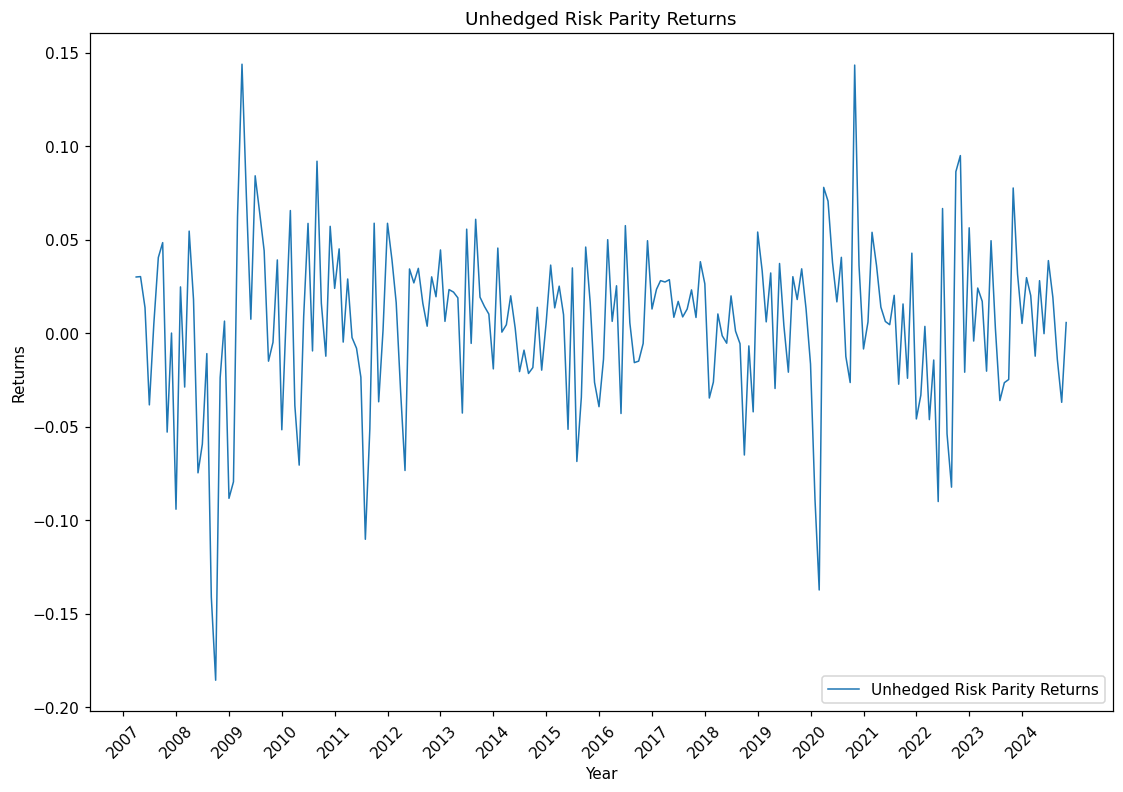

In [123]:
fig, ax = plt.subplots(figsize=(12, 8))  

# Convert 'date' column to datetime format before plotting
unhedged_risk_parity['date'] = pd.to_datetime(unhedged_risk_parity['date'])
ax.plot(unhedged_risk_parity['date'], unhedged_risk_parity['return'], linestyle='-', linewidth=1, label='Unhedged Risk Parity Returns')

years = [pd.to_datetime(str(year)) for year in range(2007, 2025)]
plt.xticks(years, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('Unhedged Risk Parity Returns')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

##### ***MVE portfolio* (assuming risk aversion = 1)**

    For currency hedged returns

**Important note :** the weights at time t are chosen at time t-1 ! In order to avoid any issues, we use our own rolling window

**2nd important note :** Rolling windows for 2009 comprise a period of crisis (2008) that yields to eratic returns. Therefore, we add a penalty epsilon for the affected window for the weights to remain stable

In [124]:
# Unhedged returns
import numpy as np
import pandas as pd

# 1. Drop the date column to get just the returns matrix
rets = hedged_returns.drop(columns='date')   # shape T×7
risk_free = r_f.drop(columns='date')

# 2. Prepare an empty DataFrame for the MV weights (same shape)
tangency_weights_hedged = pd.DataFrame(
    np.nan,
    index=rets.index,
    columns=rets.columns
)

window = 60

for t in range(window, len(rets)):
    # take the past 60 months of returns, ending at t−1
    window_rets = rets.iloc[t-window:t]                   # shape (window × 7)
    window_rf   = risk_free.iloc[t-window:t]               # shape (window,)
    # Subtract row‐wise by specifying axis=0:
    window_data = window_rets.sub(window_rf['rate']/12, axis=0)     # (60×7) array, divide by 12 since rate are yearly yields
    mu_t     = window_data.mean().values      # (7,)
    sigma_t  = window_data.cov().values       # (7×7)
    # raw MV weights  Σ^{-1} (μ-1rf)
    inv_sigma = np.linalg.inv(sigma_t)
    if t==86 or t==87: inv_sigma = np.linalg.inv(sigma_t + np.eye(sigma_t.shape[0]) * 10**(-2)) 
    w_raw = inv_sigma@mu_t
    # For Tangency Portfolio 
    tangency_weights_hedged.iloc[t] = w_raw/w_raw.sum()

    # for mve potfolio without leverage constraint
    #tangency_weights_hedged.iloc[t] = w_raw

tangency_weights_hedged = tangency_weights_hedged.dropna().reset_index(drop=True)

tangency_weights_hedged['date'] = hedged_returns['date'].iloc[window:].values

# reorder columns for ease of reading
cols = ['date'] + [c for c in tangency_weights_hedged.columns if c != 'date']
tangency_weights_hedged = tangency_weights_hedged[cols]

# Finally compute the strategy return
#    multiply each weight by its country return and sum across countries
rets_truncated = rets.iloc[window:].reset_index(drop=True)
risk_free_truncated = risk_free.iloc[window:].reset_index(drop=True)

tangency_weights_hedged['return'] = ((tangency_weights_hedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['rate']/12, axis=0)).sum(axis=1))
tangency_weights_hedged['excess_return'] = ((tangency_weights_hedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['rate']/12, axis=0)).sum(axis=1)) - risk_free_truncated['rate']/12
tangency_weights_hedged


,date,France,Australia,Germany,Japan,Switzerland,Britain,USA,return,excess_return
0,2007-04,1.220133,-1.536340,-2.085131,1.583631,3.885803,-3.762679,1.694584,0.355922,0.351960
1,2007-05,1.117415,-1.603790,-2.123117,1.671315,4.053734,-3.822639,1.707082,0.144976,0.141064
2,2007-06,1.114011,-1.575963,-1.964410,1.664764,3.752252,-3.718776,1.728122,-0.119607,-0.123383
3,2007-07,1.501321,-0.992209,-1.840459,1.352051,2.891473,-3.309449,1.397272,0.241560,0.237305
4,2007-08,1.087030,-0.587493,-1.555361,0.821822,2.211944,-2.098187,1.120245,0.145473,0.142013
...,...,...,...,...,...,...,...,...,...,...
206,2024-06,1.876180,0.122307,-0.842187,1.351132,1.792704,-1.947740,-1.352395,-0.136021,-0.140489
207,2024-07,1.078841,0.152820,-0.351593,1.400190,1.893683,-1.918962,-1.254979,0.241512,0.237048
208,2024-08,1.122822,0.159986,-0.354069,1.409871,1.906111,-1.973872,-1.270851,0.198679,0.194299
209,2024-09,1.005070,0.089280,-0.365317,1.387980,1.730688,-1.739463,-1.108238,0.070352,0.066526


In [125]:
display(tangency_weights_hedged['excess_return'].describe())

sharpe_ratio_tangency_hedged = (tangency_weights_hedged['excess_return'].mean() / tangency_weights_hedged['excess_return'].std()) * np.sqrt(12)
print(f"Sharpe Ratio: {sharpe_ratio_tangency_hedged}")

count    211.000000
mean       0.089340
std        0.189080
min       -0.537945
25%       -0.012892
50%        0.070081
75%        0.183796
max        0.689855
Name: excess_return, dtype: float64

Sharpe Ratio: 1.6367748997057348


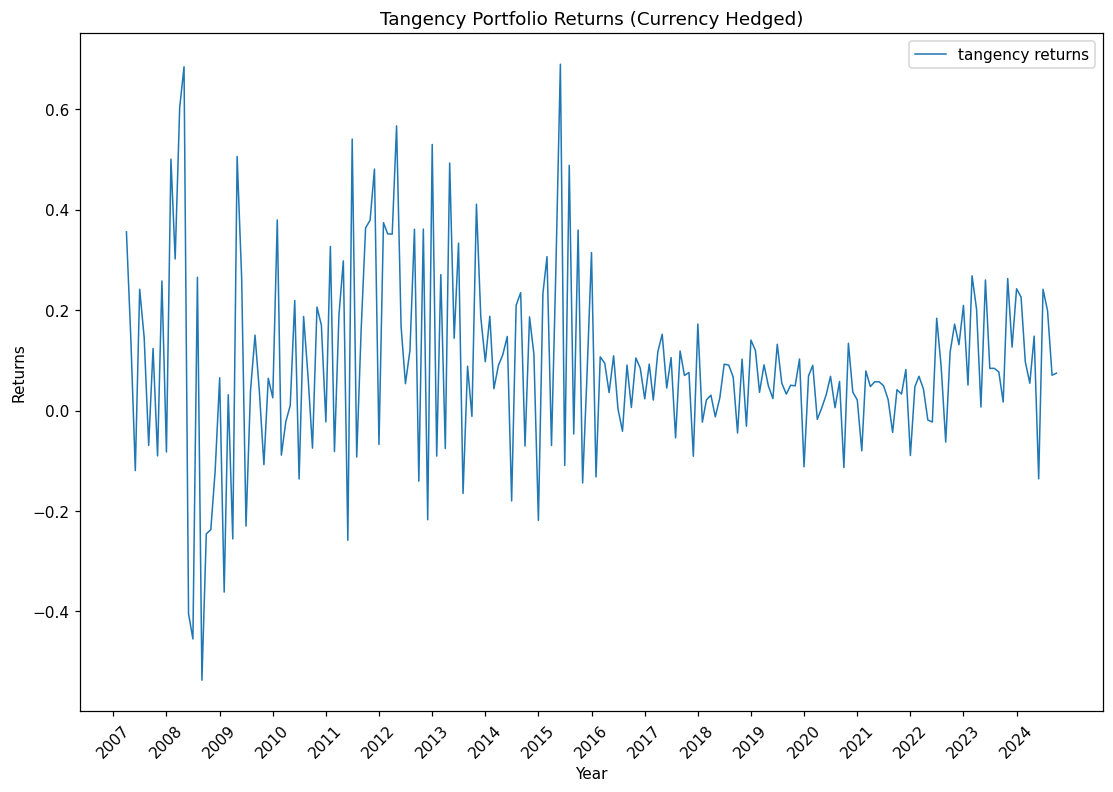

In [126]:
fig, ax = plt.subplots(figsize=(12, 8))  

ax.plot(pd.to_datetime(tangency_weights_hedged['date']), tangency_weights_hedged['return'], linestyle='-', linewidth=1, label='tangency returns')
years = [pd.to_datetime(str(year)) for year in range(2007, 2025)]
plt.xticks(years, rotation=45)
ax.tick_params(axis='x', rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('Tangency Portfolio Returns (Currency Hedged)')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

In [127]:
# Unhedged returns
import numpy as np
import pandas as pd

# 1. Drop the date column to get just the returns matrix
rets = usd_returns.drop(columns='date')   # shape T×7
risk_free = r_f.drop(columns='date')

# 2. Prepare an empty DataFrame for the MV weights (same shape)
tangency_weights_unhedged = pd.DataFrame(
    np.nan,
    index=rets.index,
    columns=rets.columns
)

window = 60

for t in range(window, len(rets)):
    # take the past 60 months of returns, ending at t−1
    window_rets = rets.iloc[t-window:t]                   # shape (window × 7)
    window_rf   = risk_free.iloc[t-window:t]               # shape (window,)
    # Subtract row‐wise by specifying axis=0:
    window_data = window_rets.sub(window_rf['rate']/12, axis=0)     # (60×7) array, divide by 12 since rate are yearly yields
    mu_t     = window_data.mean().values      # (7,)
    sigma_t  = window_data.cov().values       # (7×7)

    # raw MV weights  Σ^{-1} (μ-1rf)
    inv_sigma = np.linalg.inv(sigma_t)
    if t>=93 and t<=105: inv_sigma = np.linalg.inv(sigma_t + np.eye(sigma_t.shape[0]) * 10**(-2)) 

    w_raw = inv_sigma@mu_t

    # For Tangency Portfolio 
    tangency_weights_unhedged.iloc[t] = w_raw/w_raw.sum()

    # for mve potfolio without leverage constraint
    #tangency_weights_unhedged.iloc[t] = w_raw

tangency_weights_unhedged = tangency_weights_unhedged.dropna().reset_index(drop=True)

tangency_weights_unhedged['date'] = usd_returns['date'].iloc[window:].values

# reorder columns for ease of reading
cols = ['date'] + [c for c in tangency_weights_unhedged.columns if c != 'date']
tangency_weights_unhedged = tangency_weights_unhedged[cols]

# Finally compute the strategy return
#    multiply each weight by its country return and sum across countries
rets_truncated = rets.iloc[window:].reset_index(drop=True)
risk_free_truncated = risk_free.iloc[window:].reset_index(drop=True)

tangency_weights_unhedged['return'] = ((tangency_weights_unhedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['rate']/12, axis=0)).sum(axis=1))
tangency_weights_unhedged['excess_return'] = ((tangency_weights_unhedged.drop(columns='date') * rets_truncated.sub(risk_free_truncated['rate']/12, axis=0)).sum(axis=1)) - risk_free_truncated['rate']/12
tangency_weights_unhedged

,date,France,Australia,Germany,Japan,Switzerland,Britain,USA,return,excess_return
0,2007-04,0.566266,1.578160,-0.274043,0.052737,0.037619,-0.053609,-0.907130,0.015599,0.011637
1,2007-05,0.543010,1.492446,-0.305722,-0.059419,0.071541,-0.178127,-0.563729,0.049610,0.045698
2,2007-06,0.499124,1.488353,-0.244036,-0.105145,-0.081415,-0.125191,-0.431690,0.051709,0.047933
3,2007-07,0.575504,1.217543,-0.448909,-0.068685,-0.024902,-0.197846,-0.052706,-0.077298,-0.081553
4,2007-08,0.463202,0.857438,-0.577910,-0.009731,0.413450,-0.247024,0.100574,0.021258,0.017798
...,...,...,...,...,...,...,...,...,...,...
207,2024-07,0.663014,-1.031065,-1.785227,0.251312,-0.106926,0.445717,2.563175,0.017157,0.012694
208,2024-08,0.473986,-0.866354,-1.576123,0.337396,0.037245,0.495435,2.098415,0.008795,0.004414
209,2024-09,0.348326,-0.842447,-1.415309,0.386685,-0.004560,0.574454,1.952851,-0.036093,-0.039919
210,2024-10,0.497223,-0.921059,-1.549063,-0.097229,-0.012620,0.164279,2.918470,0.033852,0.030100


In [128]:
display(tangency_weights_unhedged['excess_return'].describe())

sharpe_ratio_tangency_unhedged = (tangency_weights_unhedged['excess_return'].mean() / tangency_weights_unhedged['excess_return'].std()) * np.sqrt(12)
print(f"Sharpe Ratio: {sharpe_ratio_tangency_unhedged}")

count    212.000000
mean      -0.001850
std        0.203295
min       -1.047197
25%       -0.062939
50%        0.013493
75%        0.063467
max        1.210827
Name: excess_return, dtype: float64

Sharpe Ratio: -0.0315256132727842


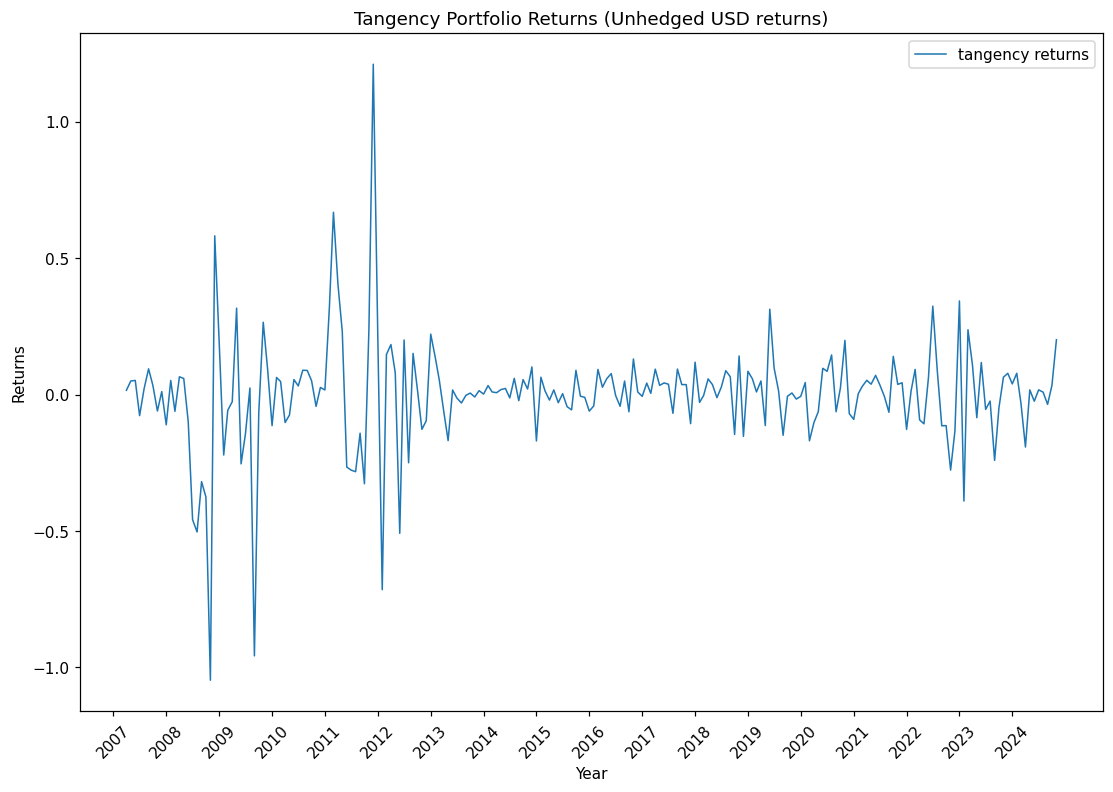

In [129]:
fig, ax = plt.subplots(figsize=(12, 8))  

ax.plot(pd.to_datetime(tangency_weights_unhedged['date']), tangency_weights_unhedged['return'], linestyle='-', linewidth=1, label='tangency returns')
years = [pd.to_datetime(str(year)) for year in range(2007, 2025)]
plt.xticks(years, rotation=45)
ax.tick_params(axis='x', rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title('Tangency Portfolio Returns (Unhedged USD returns)')
ax.set_xlabel('Year')
ax.set_ylabel('Returns')
ax.legend()
plt.show()

***Plotting the cumulative returns (cumulative wealth starting from 1 dollars)***

In [130]:
usa

,date,monthly_total_return
0,2002-04,-0.049600
1,2002-05,-0.010510
2,2002-06,-0.070259
3,2002-07,-0.081125
4,2002-08,0.007949
...,...,...
267,2024-07,0.019878
268,2024-08,0.021572
269,2024-09,0.020969
270,2024-10,-0.008298


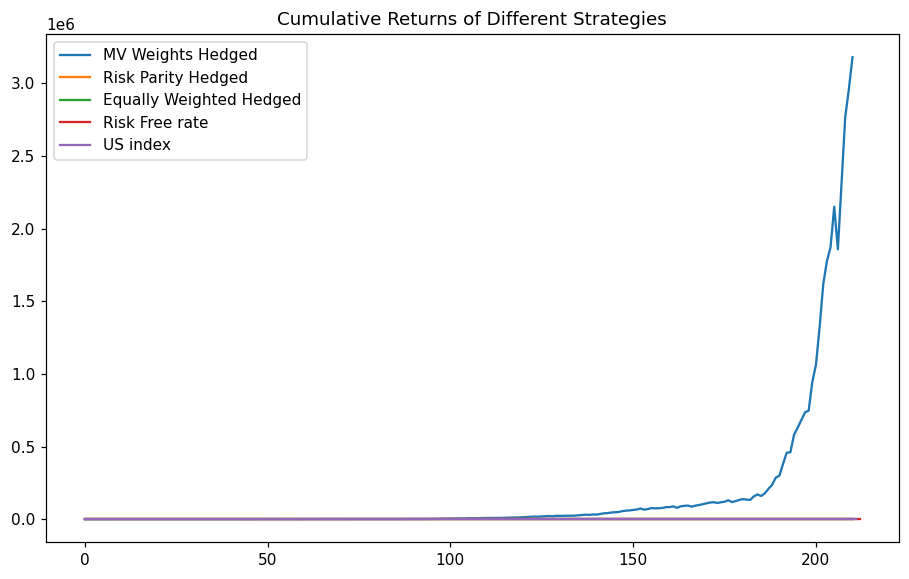

In [131]:
import matplotlib.pyplot as plt

# Plot the returns of the three strategies
plt.figure(figsize=(10, 6))
(tangency_weights_hedged['return'] + 1).cumprod().plot(label='MV Weights Hedged')
(hedged_risk_parity['return'] + 1).cumprod().plot(label='Risk Parity Hedged')
(equally_weighted_hedged['returns'].iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='Equally Weighted Hedged')
((r_f['rate']/12).iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='Risk Free rate')
(usa['monthly_total_return'].iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='US index')
plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

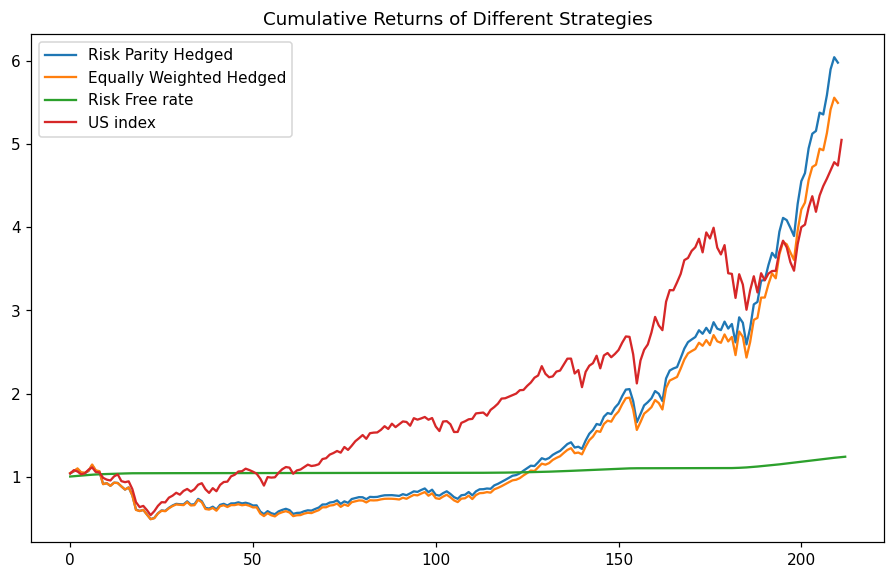

In [132]:
# Omitting tangency weights :
plt.figure(figsize=(10, 6))
#(tangency_weights_hedged['return'] + 1).cumprod().plot(label='MV Weights Hedged')
(hedged_risk_parity['return'] + 1).cumprod().plot(label='Risk Parity Hedged')
(equally_weighted_hedged['returns'].iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='Equally Weighted Hedged')
((r_f['rate']/12).iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='Risk Free rate')
(usa['monthly_total_return'].iloc[60:].reset_index(drop=True) + 1).cumprod().plot(label='US index')



plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

***Ploting the cumulative sum of the excess returns***

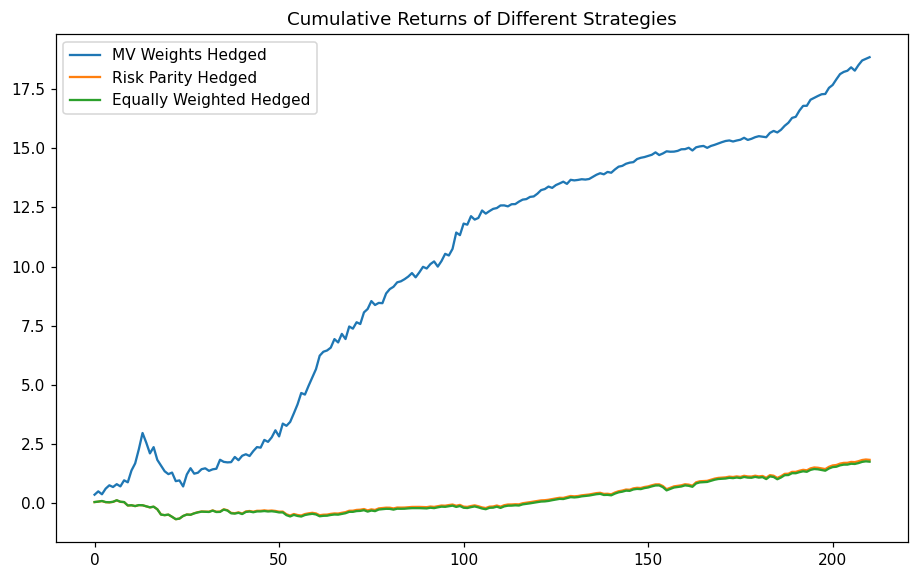

In [133]:
import matplotlib.pyplot as plt

# Plot the returns of the three strategies
plt.figure(figsize=(10, 6))
tangency_weights_hedged['excess_return'].cumsum().plot(label='MV Weights Hedged')
hedged_risk_parity['excess_returns'].reset_index(drop=True).cumsum().plot(label='Risk Parity Hedged')
equally_weighted_hedged['excess_returns'].iloc[60:].reset_index(drop=True).cumsum().plot(label='Equally Weighted Hedged')
plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

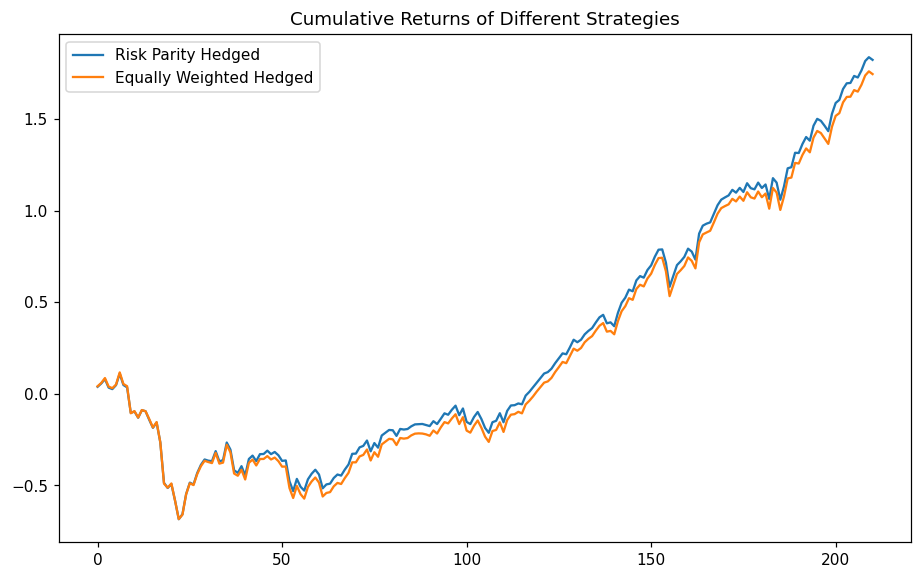

In [134]:
# omitting tangenct portfolio 
# Plot the returns of the three strategies
plt.figure(figsize=(10, 6))
#tangency_weights_hedged['excess_return'].cumsum().plot(label='MV Weights Hedged')
hedged_risk_parity['excess_returns'].reset_index(drop=True).cumsum().plot(label='Risk Parity Hedged')
equally_weighted_hedged['excess_returns'].iloc[60:].reset_index(drop=True).cumsum().plot(label='Equally Weighted Hedged')
plt.legend()
plt.title('Cumulative Returns of Different Strategies')
plt.show()

***Plotting the Sharpe ratios of the different strategies***

In [135]:
sharpe_ratio_USD = np.sqrt(12)*(usa['monthly_total_return'] - r_f['rate']/12).mean()/(usa['monthly_total_return'].std()) 

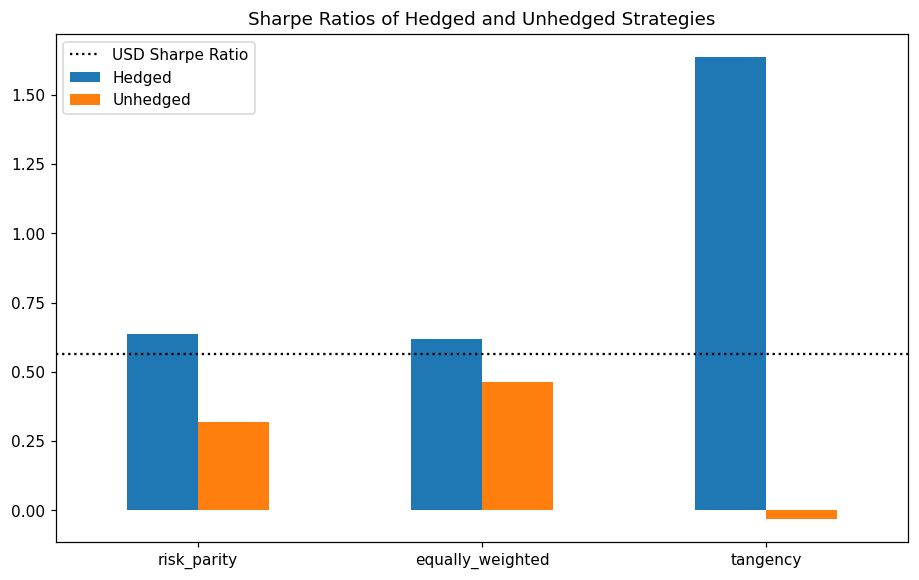

In [136]:
sharpe_ratios = pd.DataFrame({'Hedged': {'risk_parity': sharpe_ratio_hedged_div, 'equally_weighted': sharpe_ratio_equally_hedged, 'tangency': sharpe_ratio_tangency_hedged}, 
                              'Unhedged': {'risk_parity':sharpe_ratio_unhedged_div, 'equally_weighted': sharpe_ratio_equally_unhedged, 'tangency': sharpe_ratio_tangency_unhedged}})

sharpe_ratios.plot(kind='bar', figsize=(10, 6))
plt.xticks(rotation=0)
plt.title('Sharpe Ratios of Hedged and Unhedged Strategies')
plt.axhline(sharpe_ratio_USD, color='black', linestyle=':', label='USD Sharpe Ratio')
plt.legend(['USD Sharpe Ratio', 'Hedged', 'Unhedged'])
plt.show()



# **4. Equity Index Momentum Strategy**

***4.a*** We construct the return of a long-short momentum strategy portfolio. To that effect, every month we sort currency-hedged stock indexes based on their 1-month-lagged 11-month return (that is, in month $t$ we rank stocks based on their $t-12$ to $t-1$ cumulative return). Call $\mathrm{Rank}^i_t$ the corresponding rank of index $i$ at time $t$ (e.g., $\mathrm{Rank}^i_t = 2$ if country $i$ has the second-lowest currency-hedged return over the last year).

We compute monthly returns to a portfolio that invests in index $i$ the weight

$$
w^i_t \;=\; Z\Bigl(\mathrm{Rank}^i_t \;-\; \frac{N+1}{2}\Bigr)
$$

for all $i = 1, \dots, N$, where:
- $N$ is the total number of stock indexes traded, and  
- $Z$ is a factor that ensures
  $$
    \sum_{i:\,\mathrm{Rank}^i_t > \frac{N+1}{2}} w^i_t \;=\; +1 
    \quad\text{and}\quad
    \sum_{i:\,\mathrm{Rank}^i_t < \frac{N+1}{2}} w^i_t \;=\; -1.
$$

Because we have $\frac{N+1}{2} = 4$, the positive weights will be +1, +2 and +3, meaning that we should choose $Z = \frac{1}{6}$

In [137]:
#  Shift series by 1 to drop the return in t-1
lagged = hedged_returns.drop(columns='date').shift(1)

# Rolling‐window product over the prior 11 months
cumret = lagged.add(1) \
               .rolling(window=11) \
               .apply(np.prod, raw=True) \
               .subtract(1)

# Compute the ranks
ranks = cumret.rank(axis=1, method='first')  
ranks.head(20)

N = hedged_returns.drop(columns='date').shape[1]

# Compute the weights
w = ranks.subtract(4).div(N-1)

mom_return = (w * hedged_returns).sum(axis=1)

# put it all together
momentum = pd.DataFrame({
    'weight_'+col: w[col] for col in w.columns
})
momentum['momentum_return'] = mom_return.values

# Ensure date column is correctly aligned
momentum['date'] = hedged_returns['date']

momentum = momentum[['date'] + [col for col in momentum.columns if col != 'date']]

momentum = momentum.dropna()
momentum = momentum.reset_index(drop=True)
momentum

,date,weight_France,weight_Australia,weight_Germany,weight_Japan,weight_Switzerland,weight_Britain,weight_USA,momentum_return
0,2003-03,-0.333333,0.000000,-0.500000,0.500000,0.166667,-0.166667,0.333333,0.072595
1,2003-04,-0.333333,0.000000,-0.500000,0.500000,0.166667,-0.166667,0.333333,-0.088498
2,2003-05,0.000000,-0.500000,-0.333333,0.500000,0.166667,-0.166667,0.333333,0.025324
3,2003-06,0.000000,-0.500000,-0.333333,0.333333,0.166667,-0.166667,0.500000,0.034871
4,2003-07,0.000000,-0.500000,-0.166667,0.333333,0.166667,-0.333333,0.500000,0.044207
...,...,...,...,...,...,...,...,...,...
255,2024-06,0.000000,-0.166667,0.166667,0.500000,0.333333,-0.500000,-0.333333,-0.014136
256,2024-07,-0.333333,0.166667,0.000000,0.500000,0.333333,-0.500000,-0.166667,0.057487
257,2024-08,-0.333333,-0.166667,0.166667,0.500000,0.333333,-0.500000,0.000000,0.031348
258,2024-09,-0.166667,0.000000,0.166667,0.500000,0.333333,-0.500000,-0.333333,0.014434


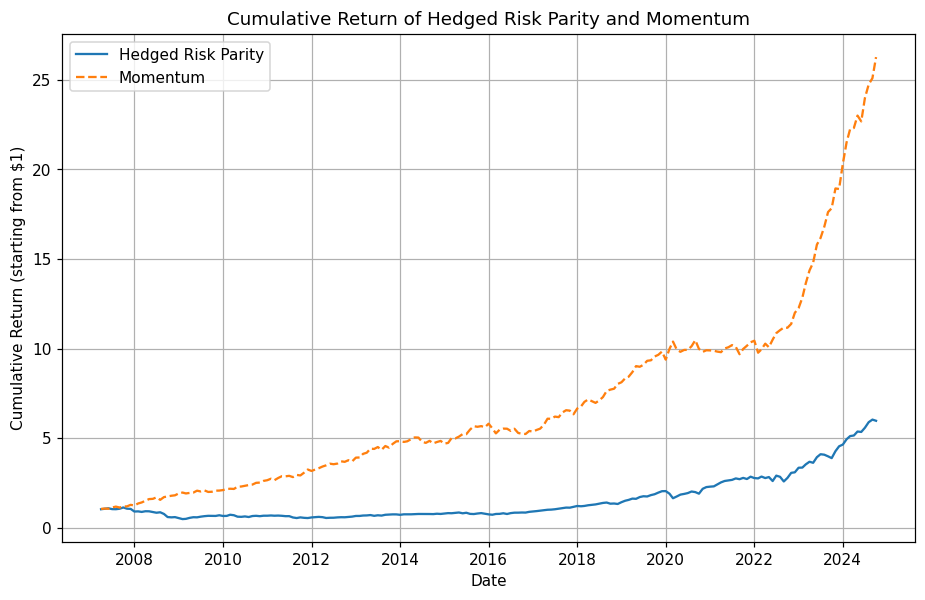

In [138]:
import matplotlib.pyplot as plt

# Convert 'date' column to datetime
hedged_risk_parity['date'] = pd.to_datetime(hedged_risk_parity['date'])
momentum['date'] = pd.to_datetime(momentum['date'])

# Plotting the cumulative return of hedged risk parity and momentum
plt.figure(figsize=(10, 6))
plt.plot(hedged_risk_parity.date, (1 + hedged_risk_parity['return']).cumprod().reset_index(drop=True), label='Hedged Risk Parity')
plt.plot(momentum[momentum['date'] >= hedged_risk_parity['date'].min()].date, (1 + momentum[momentum['date'] >= hedged_risk_parity['date'].min()]['momentum_return']).cumprod().reset_index(drop=True), label='Momentum', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (starting from $1)')
plt.title('Cumulative Return of Hedged Risk Parity and Momentum')
plt.legend()
plt.grid()
plt.show()


In [139]:
# Merge the momentum and hedged risk parity dataframes on the 'date' column
div_mom_returns = pd.merge(momentum[['date', 'momentum_return']], hedged_risk_parity[['date', 'return']], on='date', how='inner')

# Rename the 'return' column to 'DIV_return'
div_mom_returns = div_mom_returns.rename(columns={'return': 'DIV_return'})

# Display the merged dataframe
div_mom_returns.to_csv('div_mom_returns.csv', index=False)

***4.b*** We compute the mean, standard deviation, and Sharpe ratios of the long
and short legs of the strategy as well as of the strategy itself. Furthermore, we test if the strategy has
an average return that is statistically significantly different from zero.


In [140]:
# Initialize the dataframes
long_strategy, short_strategy = pd.DataFrame(), pd.DataFrame()
short_strategy['date'], long_strategy['date'] = hedged_returns['date'], hedged_returns['date']

#Compute the long and short strategies returns
long_strategy['return'] = (w[w > 0] * hedged_returns.drop(columns='date')).sum(axis=1)
short_strategy['return'] = (w[w < 0] * hedged_returns.drop(columns='date')).sum(axis=1)

# Compute the long and short strategies excess returns
long_strategy['excess_return'] = long_strategy['return'] - r_f[r_f['date'].isin(long_strategy['date'])]['rate']/12
short_strategy['excess_return'] = short_strategy['return'] - r_f[r_f['date'].isin(short_strategy['date'])]['rate']/12

#drop the 11 nan values due to rolling window used earlier
long_strategy, short_strategy = long_strategy.iloc[11:].reset_index(drop=True), short_strategy.iloc[11:].reset_index(drop=True)

In [141]:
print('long leg : \n', long_strategy['return'].describe())
long_strategy_sharpe = (long_strategy['excess_return'].mean() / long_strategy['return'].std())*np.sqrt(12)
print('Long Strategy Sharpe Ratio: ', long_strategy_sharpe)

print('\nshort leg : \n', short_strategy['return'].describe())
short_strategy_sharpe = (short_strategy['excess_return'].mean() / short_strategy['return'].std())*np.sqrt(12)
print('Short Strategy Sharpe Ratio: ', short_strategy_sharpe)

long leg : 
 count    260.000000
mean       0.020573
std        0.046906
min       -0.192297
25%       -0.005759
50%        0.025225
75%        0.047771
max        0.137483
Name: return, dtype: float64
Long Strategy Sharpe Ratio:  1.427935756278268

short leg : 
 count    260.000000
mean      -0.000375
std        0.049167
min       -0.176921
25%       -0.028457
50%       -0.007624
75%        0.024378
max        0.213134
Name: return, dtype: float64
Short Strategy Sharpe Ratio:  -0.1136685327289027


In [142]:
# Momentum mean and std
print('momentum strategy : \n', momentum['momentum_return'].describe())

momentum strategy : 
 count    260.000000
mean       0.020198
std        0.030558
min       -0.088498
25%        0.002369
50%        0.020610
75%        0.040391
max        0.097205
Name: momentum_return, dtype: float64


In [143]:
# Momentum Sharpe Ratio
momentum_strategy_sharpe = (momentum['momentum_return'].mean() / momentum['momentum_return'].std())*np.sqrt(12)
print('Momentum Strategy Sharpe Ratio: ', momentum_strategy_sharpe)

Momentum Strategy Sharpe Ratio:  2.289683917617084


In [144]:
#Hypothesis testing
from scipy.stats import ttest_1samp

# Perform the t-test
t_stat, p_val = ttest_1samp(momentum['momentum_return'], 0)

print('T-statistic: ', t_stat)
print('P-value: ', p_val)

if p_val < 0.05:
    print('Reject the null hypothesis: The average return of momentum might be different than 0')
else:
    print('Fail to reject the null hypothesis: The average return of momentum is not statiscally significant')

T-statistic:  10.657898616654075
P-value:  3.139487812583878e-22
Reject the null hypothesis: The average return of momentum might be different than 0


***4.c***  We regress the MOM strategy return on the DIV return

In [145]:
import statsmodels.api as sm

X = div_mom_returns['DIV_return']
y = div_mom_returns['momentum_return']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        momentum_return   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.236
Date:                Fri, 06 Jun 2025   Prob (F-statistic):              0.268
Time:                        11:43:03   Log-Likelihood:                 445.88
No. Observations:                 211   AIC:                            -887.8
Df Residuals:                     209   BIC:                            -881.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0165      0.002      7.990      0.0

*Interpretation :*    

**intepretation of the intercept** : the fitted model predicts the momentum strategy will (on average) earns about +1.65% more than DIV (ie. even if in one month the DIV earns 0% return, MOM will earn 1.65%). In other words, momentum has a significantly positive average return compared to DIV. Besides, the p-value lower than 5% threshold indicates that the value for the intercept is statistically significant.

**interpretation of coefficient on DIV_return** : The point estimate suggests a small negative relationship : when DIV_return goes up by 1 percentage point, the model predicts the momentum return falls by about 0.0478 percentage points. However, this slope is not statistically significant (p ≈ 0.268 > 0.05), and its 95% confidence interval [−0.133,0.037] includes zero. That means we do not have evidence that DIV returns systematically forecast (or inversely forecast) momentum returns.

**interpretation of R2 and F-statistic** : The R² of 0.006 and an F-statistic p-value of 0.268 indicate that almost none of the variation in momentum returns is explained by dividend returns.

**What this means for a DIV investor** : Because the estimated slope $\beta$ is small and not statistically different from zero, and because $R^2$ is nearly zero, we conclude that momentum strategy returns are essentially independent of risk-parity portfolio returns. In other words, holding a pure risk-parity portfolio does not predict or replicate momentum returns; the two approaches move largely independently.
Moreover, the regression intercept of approximately 1.65% per month is highly significant. This indicates that momentum has generated positive average returns that are not captured by risk-parity. Even though the coefficient on risk-parity returns is insignificant, the positive constant shows that momentum provides its own source of return.

Taken together, these findings imply that an investor who already allocates to a risk-parity portfolio could benefit from adding a momentum allocation. Because the two portfolios appear to move independantly, combining the two strategies can deliver diversification. At the same time, momentum’s positive average return suggests that a risk-parity investor who also holds momentum can boost expected return and potentially reduce overall portfolio volatility, since the two portfolio returns are almost uncorrelated.

*Note* : we try again to see if allowing for heteroskedasticity in the model changes the results :

In [146]:
X = div_mom_returns['DIV_return']
y = div_mom_returns['momentum_return']

X = sm.add_constant(X)

model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
predictions = model.predict(X)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:        momentum_return   No. Observations:                  211
Model:                            RLM   Df Residuals:                      209
Method:                          IRLS   Df Model:                            1
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Fri, 06 Jun 2025                                         
Time:                        11:43:03                                         
No. Iterations:                    20                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0176      0.002      8.605      0.000       0.014       0.022
DIV_return    -0.0557      0.043     -1.307      0.191      -0.139       0.028
==============================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

The conclusions remain more or less the same as for the homoskedastic model discussed earlier.

# **5.Equity Index Long Term Reversal strategy (REV)**


In [147]:
lagged_hedged = hedged_returns.drop(columns='date').shift(12)  # shift by 12 months
rev_cumret = lagged_hedged.add(1).rolling(window=49).apply(np.prod, raw=True).subtract(1)  # 49 = 60-12+1

rev_ranks = rev_cumret.rank(axis=1, method='first', ascending=True)

N = rev_cumret.shape[1]               # number of indices
m = N // 2                            # losers (or winners) in each half
Z = 2 / (m * (N - m))                 # = 8/N² if N even, 8/(N²–1) if N odd

#here Z has the same value as for the question 4.a (Z=1/6), the only difference is that signs of winners/losers are reversed

rev_weights = Z * ((N + 1) / 2 - rev_ranks) #compute weights

rev_returns = (rev_weights * hedged_returns.drop(columns='date')).sum(axis=1) #compute returns

valid_rows = rev_cumret.notna().all(axis=1)

rev_strategy = pd.DataFrame({
    'date': hedged_returns['date'],
    'rev_return': rev_returns
})[valid_rows].reset_index(drop=True)

rev_strategy

,date,rev_return
0,2007-04,-0.040651
1,2007-05,-0.025903
2,2007-06,0.029564
3,2007-07,-0.075682
4,2007-08,-0.043633
...,...,...
206,2024-06,0.022696
207,2024-07,-0.058889
208,2024-08,-0.043942
209,2024-09,-0.007956


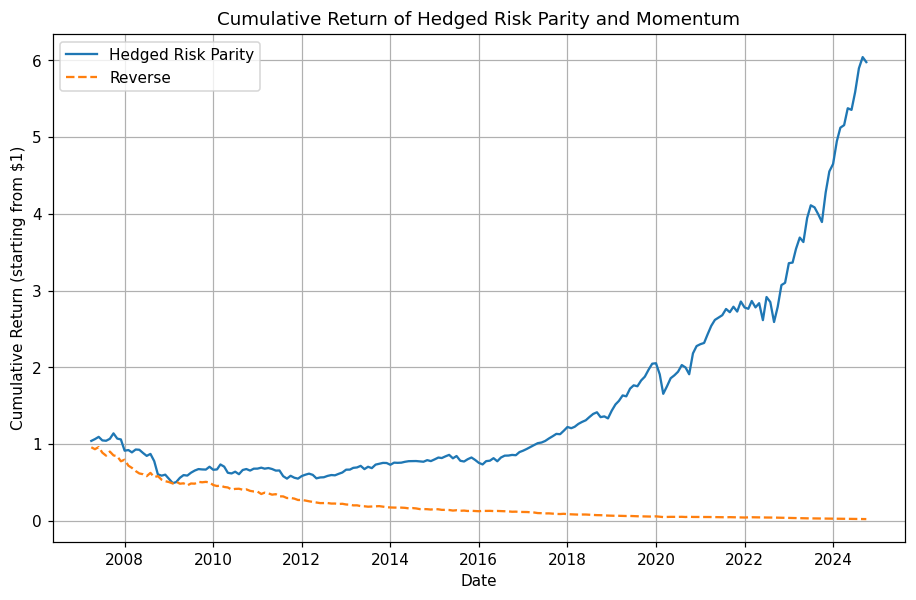

In [148]:
# Convert 'date' column to datetime
hedged_risk_parity['date'] = pd.to_datetime(hedged_risk_parity['date'])
rev_strategy['date'] = pd.to_datetime(rev_strategy['date'])

# Plotting the cumulative return of hedged risk parity and rev strategy
plt.figure(figsize=(10, 6))
plt.plot(hedged_risk_parity.date, (1 + hedged_risk_parity['return']).cumprod().reset_index(drop=True), label='Hedged Risk Parity')
plt.plot(rev_strategy[rev_strategy['date'] >= hedged_risk_parity['date'].min()].date, (1 + rev_strategy[rev_strategy['date'] >= hedged_risk_parity['date'].min()]['rev_return']).cumprod().reset_index(drop=True), label='Reverse', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (starting from $1)')
plt.title('Cumulative Return of Hedged Risk Parity and Momentum')
plt.legend()
plt.grid()
plt.show()

***5.b*** We compute the mean, standard deviation, and Sharpe ratios of the long and short legs of the strategy as well as of the strategy itself.  

We also test if the strategy has an average return that is statistically significantly different from zero.



In [149]:
# Initialize the dataframes
long_strategy_rev, short_strategy_rev = pd.DataFrame(), pd.DataFrame()
short_strategy_rev['date'], long_strategy_rev['date'] = hedged_returns['date'], hedged_returns['date']

#Compute the long and short leg strategies returns
long_strategy_rev['return'] = (rev_weights[rev_weights > 0] * hedged_returns.drop(columns='date')).sum(axis=1)
short_strategy_rev['return'] = (rev_weights[rev_weights < 0] * hedged_returns.drop(columns='date')).sum(axis=1)

# Compute the long and short leg strategies excess returns
long_strategy_rev['excess_return'] = long_strategy_rev['return'] - r_f[r_f['date'].isin(long_strategy_rev['date'])]['rate']/12
short_strategy_rev['excess_return'] = short_strategy_rev['return'] - r_f[r_f['date'].isin(short_strategy_rev['date'])]['rate']/12


#drop the 60 nan values due to rolling window used earlier
long_strategy_rev, short_strategy_rev = long_strategy_rev.iloc[60:].reset_index(drop=True), short_strategy_rev.iloc[60:].reset_index(drop=True)

In [150]:
print('long leg rev strategy: \n', long_strategy_rev['return'].describe())
long_leg_rev_strategy_sharpe = (long_strategy_rev['excess_return'].mean() / long_strategy_rev['return'].std())*np.sqrt(12)
print('Long leg rev Strategy Sharpe Ratio: ', long_leg_rev_strategy_sharpe)

print('\nshort leg rev strategy: \n', short_strategy_rev['return'].describe())
short_leg_rev_strategy_sharpe = (short_strategy_rev['excess_return'].mean() / short_strategy_rev['return'].std())*np.sqrt(12)
print('Short leg rev Strategy Sharpe Ratio: ', short_leg_rev_strategy_sharpe)

long leg rev strategy: 
 count    211.000000
mean      -0.000982
std        0.050858
min       -0.203136
25%       -0.025074
50%        0.005834
75%        0.029265
max        0.120475
Name: return, dtype: float64
Long leg rev Strategy Sharpe Ratio:  -0.1347485792519676

short leg rev strategy: 
 count    211.000000
mean      -0.016093
std        0.048225
min       -0.163661
25%       -0.046678
50%       -0.019459
75%        0.007550
max        0.226675
Name: return, dtype: float64
Short leg rev Strategy Sharpe Ratio:  -1.2275479511852652


In [151]:
# Reversal strategy mean and std
print('Reversal strategy : \n', rev_strategy['rev_return'].describe())

Reversal strategy : 
 count    211.000000
mean      -0.017075
std        0.030750
min       -0.097442
25%       -0.035726
50%       -0.020279
75%        0.001079
max        0.072455
Name: rev_return, dtype: float64


In [152]:
# Reversal strategy Sharpe Ratio
reversal_strategy_sharpe = (rev_strategy['rev_return'].mean() / rev_strategy['rev_return'].std())*np.sqrt(12)
print('Reversal Strategy Sharpe Ratio: ', reversal_strategy_sharpe)

Reversal Strategy Sharpe Ratio:  -1.923576820920567


In [153]:
# Perform the t-test
t_stat, p_val = ttest_1samp(rev_strategy['rev_return'], 0)

print('T-statistic: ', t_stat)
print('P-value: ', p_val)

if p_val < 0.05:
    print('Reject the null hypothesis: The average return of Reversal might be different than 0')
else:
    print('Fail to reject the null hypothesis: The average return of Reversal is not statiscally significant')

T-statistic:  -8.066035699371296
P-value:  5.4951321738896397e-14
Reject the null hypothesis: The average return of Reversal might be different than 0


***5.c*** We regress the Rev strategy return on the DIV return



In [154]:
X = div_mom_returns['DIV_return']
y = rev_strategy['rev_return']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rev_return   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.283
Date:                Fri, 06 Jun 2025   Prob (F-statistic):              0.259
Time:                        11:43:03   Log-Likelihood:                 436.42
No. Observations:                 211   AIC:                            -868.8
Df Residuals:                     209   BIC:                            -862.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0176      0.002     -8.134      0.000      -0.022      -0.013
DIV_return     0.0510      0.045      1.133      0.259      -0.038       0.140
==============================================================================
Omnibus:                        4.550   Durbin-Watson:                   2.671
Prob(Omnibus):                  0.103   Jarque-Bera (JB):                4.151
Skew:                           0.314   Prob(JB):                        0.125
Kurtosis:                       3.280   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# **Part 6 : Currency Carry Strategy (CARRY)**

***6.a*** Construct the return to a long-short currency carry strategy portfolio. To that effect every month sort currency returns based on their interest rate differential (i.e., the ‘carry’ is defined as the foreign risk-free 3-month interest rate minus the 3-month USD risk-free rate).

In [155]:
excess_ret_currencies = excess_ret.drop(columns=['Germany','USA']).rename(columns={'France':'EUR', 'Australia':'AUD', 'Japan':'JPY', 'Switzerland':'CHF', 'Britain':'GBP'})
excess_ret_currencies

,date,EUR,AUD,JPY,CHF,GBP
0,04-2002,0.060589,0.065287,0.007638,0.025625,0.040389
1,05-2002,0.057012,0.005972,0.028570,0.040198,0.074792
2,06-2002,0.000171,0.008205,-0.026199,-0.025005,0.009535
3,07-2002,0.018861,0.042383,-0.033835,-0.007852,0.035760
4,08-2002,0.016134,0.038703,-0.039655,-0.011537,0.023089
...,...,...,...,...,...,...
266,06-2024,0.000285,-0.010848,0.025631,-0.001296,0.003924
267,07-2024,-0.007831,0.010159,-0.025436,-0.027771,0.020106
268,08-2024,-0.033731,-0.015197,-0.092438,-0.054917,-0.014159
269,09-2024,-0.040479,-0.028904,-0.068566,-0.059704,-0.023195


In [156]:
# List of currencies used in the carry strategy (excluding USD)
currencies = ['EUR', 'AUD', 'JPY', 'CHF', 'GBP']
N = len(currencies)

# Initialize list to store strategy returns
carry_returns = []

# Loop over each row (date) in excess_ret
for i in range(len(excess_ret_currencies)):
    row = excess_ret_currencies.iloc[i]
    date = row['date']
    
    # 1. Compute carry (interest rate differential)
    carry_scores = {}
    try:
        carry_scores['EUR'] = eur_rate['borrowing_rate'].iloc[i] - usd_rate['borrowing_rate'].iloc[i]
        carry_scores['AUD'] = aud_rate['borrowing_rate'].iloc[i] - usd_rate['borrowing_rate'].iloc[i]
        carry_scores['JPY'] = jpy_rate['borrowing_rate'].iloc[i] - usd_rate['borrowing_rate'].iloc[i]
        carry_scores['CHF'] = chf_rate['borrowing_rate'].iloc[i] - usd_rate['borrowing_rate'].iloc[i]
        carry_scores['GBP'] = gbp_rate['borrowing_rate'].iloc[i] - usd_rate['borrowing_rate'].iloc[i]
    except IndexError:
        # Skip if rate data is missing
        continue

    # 2. Rank based on carry (ascending → lower carry = lower rank)
    ranks = pd.Series(carry_scores).rank(method='first', ascending=True)
    
    # 3. Compute weights using Z * (Rank - (N+1)/2)
    weights = ranks - (N + 1) / 2
    Z = 1/3
    weights *= Z
    # 4. Compute weighted return using excess returns X_t+1 from excess_ret
    weighted_returns = {currency: weights[currency] * row[currency] for currency in currencies}
    R_CARRY = sum(weighted_returns.values())

    # 5. Track long and short averages for analysis
    long_return = sum(weighted_returns[c] for c in currencies if weights[c] > 0)
    short_return = sum(weighted_returns[c] for c in currencies if weights[c] < 0)

    # 6. Append result
    carry_returns.append({
        'date': date,
        'carry_return': R_CARRY,
        'long_return': long_return,
        'short_return': short_return,
        'long_excess': long_return - r_f['rate'].iloc[i]/12,
        'short_excess': short_return - r_f['rate'].iloc[i]/12,
    })

# Final DataFrame
carry_strategy_df = pd.DataFrame(carry_returns)
carry_strategy_df['date'] = pd.to_datetime(carry_strategy_df['date'], format="%m-%Y")
carry_strategy_df = carry_strategy_df.sort_values('date').reset_index(drop=True)

In [157]:
# Display head and describe performance
display(carry_strategy_df)
print("\nSummary Statistics for Currency Carry Strategy (Part 6a):")
print(carry_strategy_df['carry_return'].describe())

,date,carry_return,long_return,short_return,long_excess,short_excess
0,2002-04-01,0.043353,0.056987,-0.013634,0.055527,-0.015095
1,2002-05-01,-0.003534,0.028912,-0.032446,0.027504,-0.033854
2,2002-06-01,0.034449,0.008648,0.025801,0.007259,0.024412
3,2002-07-01,0.065349,0.040175,0.025174,0.038759,0.023758
4,2002-08-01,0.063781,0.033499,0.030283,0.032118,0.028902
...,...,...,...,...,...,...
266,2024-06-01,-0.017655,-0.001000,-0.016655,-0.005467,-0.021123
267,2024-07-01,0.043004,0.016790,0.026214,0.012326,0.021750
268,2024-08-01,0.065426,-0.014505,0.079931,-0.018885,0.075551
269,2024-09-01,0.040514,-0.025098,0.065612,-0.028924,0.061786



Summary Statistics for Currency Carry Strategy (Part 6a):
count    271.000000
mean       0.030201
std        0.026612
min       -0.114898
25%        0.013529
50%        0.029825
75%        0.049201
max        0.105735
Name: carry_return, dtype: float64


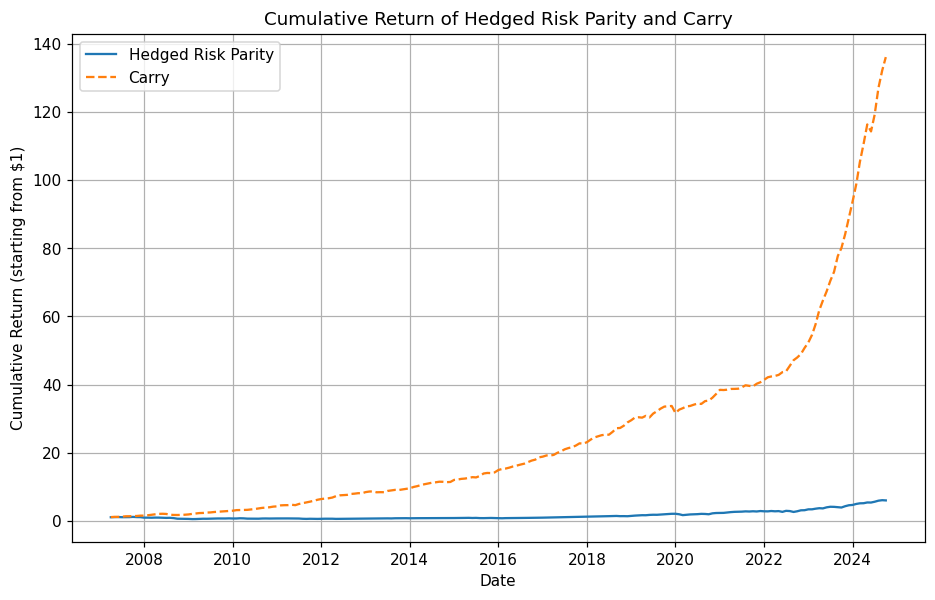

In [158]:
### Plots of carry cumulative return vs DIV
hedged_risk_parity['date'] = pd.to_datetime(hedged_risk_parity['date'])
carry_strategy_df['date'] = pd.to_datetime(carry_strategy_df['date'])

# Plotting the cumulative return of hedged risk parity and carry
plt.figure(figsize=(10, 6))
plt.plot(hedged_risk_parity.date, (1 + hedged_risk_parity['return']).cumprod().reset_index(drop=True), label='Hedged Risk Parity')
plt.plot(carry_strategy_df[carry_strategy_df['date'] >= hedged_risk_parity['date'].min()].date, (1 + carry_strategy_df[carry_strategy_df['date'] >= hedged_risk_parity['date'].min()]['carry_return']).cumprod().reset_index(drop=True), label='Carry', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (starting from $1)')
plt.title('Cumulative Return of Hedged Risk Parity and Carry')
plt.legend()
plt.grid()
plt.show()

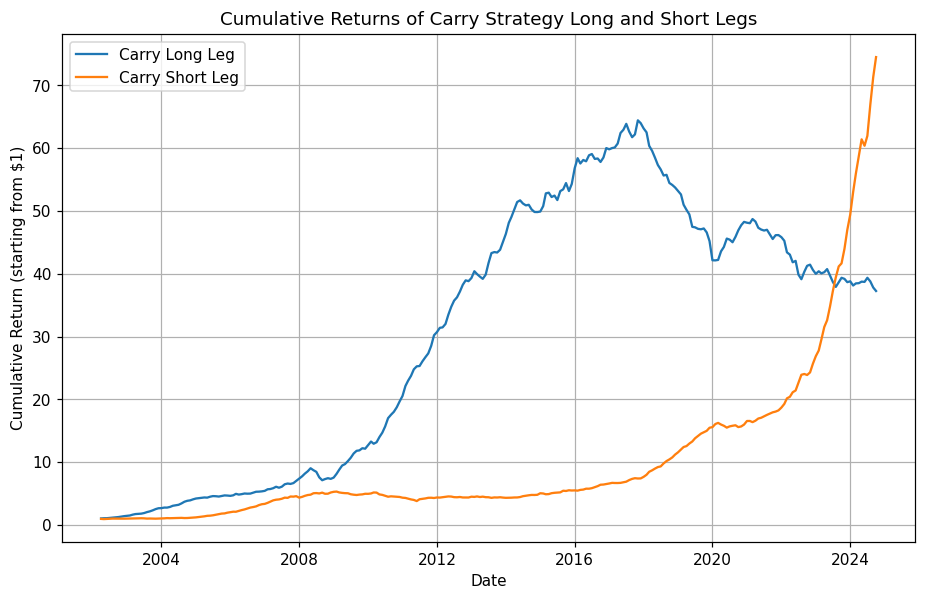

In [159]:
# cumulative returns of carry strategy long and short legs
plt.figure(figsize=(10, 6))
plt.plot(carry_strategy_df['date'], (1 + carry_strategy_df['long_return']).cumprod(), label='Carry Long Leg')
plt.plot(carry_strategy_df['date'], (1 + carry_strategy_df['short_return']).cumprod(), label='Carry Short Leg')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (starting from $1)')
plt.title('Cumulative Returns of Carry Strategy Long and Short Legs')
plt.legend()
plt.grid()
plt.show()


***6.b*** 

In [160]:
from scipy import stats

# Annualization factor (monthly returns)
ANNUALIZER = np.sqrt(12)

# Compute mean, std, Sharpe
carry_stats = {
    "Strategy Mean": carry_strategy_df['carry_return'].mean(),
    "Strategy Std": carry_strategy_df['carry_return'].std(),
    "Strategy Sharpe": carry_strategy_df['carry_return'].mean() / carry_strategy_df['carry_return'].std() * ANNUALIZER,

    "Long Leg Mean": carry_strategy_df['long_return'].mean(),
    "Long Leg Std": carry_strategy_df['long_return'].std(),
    "Long Leg Sharpe": carry_strategy_df['long_excess'].mean() / carry_strategy_df['long_excess'].std() * ANNUALIZER,

    "Short Leg Mean": carry_strategy_df['short_return'].mean(),
    "Short Leg Std": carry_strategy_df['short_return'].std(),

    "Short Leg Sharpe": carry_strategy_df['short_excess'].mean() / carry_strategy_df['short_excess'].std() * ANNUALIZER
}

# T-test: is average return significantly different from 0?
t_stat, p_value = stats.ttest_1samp(carry_strategy_df['carry_return'], 0)

# Display stats
print("=== Currency Carry Strategy Performance (6b) ===")
for key, val in carry_stats.items():
    print(f"{key:<20}: {val:.4f}")
print(f"\nT-Test on Mean Return:")
print(f"  t-statistic: {t_stat:.4f}\n p-value: {p_value:.4f}")

=== Currency Carry Strategy Performance (6b) ===
Strategy Mean       : 0.0302
Strategy Std        : 0.0266
Strategy Sharpe     : 3.9312
Long Leg Mean       : 0.0138
Long Leg Std        : 0.0288
Long Leg Sharpe     : 1.5031
Short Leg Mean      : 0.0164
Short Leg Std       : 0.0256
Short Leg Sharpe    : 2.1188

T-Test on Mean Return:
  t-statistic: 18.6820
 p-value: 0.0000


***6.c*** 

In [161]:
import statsmodels.api as sm

# Prepare data
carry_series = carry_strategy_df[['date', 'carry_return']].copy()
div_series = hedged_risk_parity[['date', 'return']].copy().rename(columns={'return': 'DIV_return'})

# Merge and drop missing
regression_df = pd.merge(carry_series, div_series, on='date', how='inner').dropna()

# Regression: CARRY ~ DIV
X = sm.add_constant(regression_df['DIV_return'])  # predictor
y = regression_df['carry_return']                 # response

model = sm.OLS(y, X).fit()
print("=== Regression Results: CARRY ~ DIV ===")
print(model.summary())

=== Regression Results: CARRY ~ DIV ===
                            OLS Regression Results                            
Dep. Variable:           carry_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.1197
Date:                Fri, 06 Jun 2025   Prob (F-statistic):              0.730
Time:                        11:43:03   Log-Likelihood:                 474.65
No. Observations:                 211   AIC:                            -945.3
Df Residuals:                     209   BIC:                            -938.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

# **7. Currency dollar Strategy (DOLLAR)**

***7.a*** We construct the return to a **long-dollar versus rest of the world** strategy portfolio. That portfolio simply goes short an equal-weighted basket of all the foreign currencies against the dollar. Its return is then simply:

$$
R^{\text{DOLLAR}}_{t+1} = \sum_{i=1}^{N} \frac{1}{N} X^{i}_{t+1}
$$

where $X^{i}_{t+1}$ is the **excess return on currency  $i$**  and $N$ denotes the total number of foreign currencies traded.

In [162]:
dollar = pd.DataFrame()
dollar['date'] = excess_ret_currencies['date']
dollar['return'] = excess_ret_currencies.drop(columns='date').sum(axis=1)/5
dollar

,date,return
0,04-2002,0.039906
1,05-2002,0.041309
2,06-2002,-0.006659
3,07-2002,0.011063
4,08-2002,0.005347
...,...,...
266,06-2024,0.003539
267,07-2024,-0.006155
268,08-2024,-0.042088
269,09-2024,-0.044170


C:\Users\benka\AppData\Local\Temp\ipykernel_86012\4149403752.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dollar['date'] = pd.to_datetime(dollar['date'])


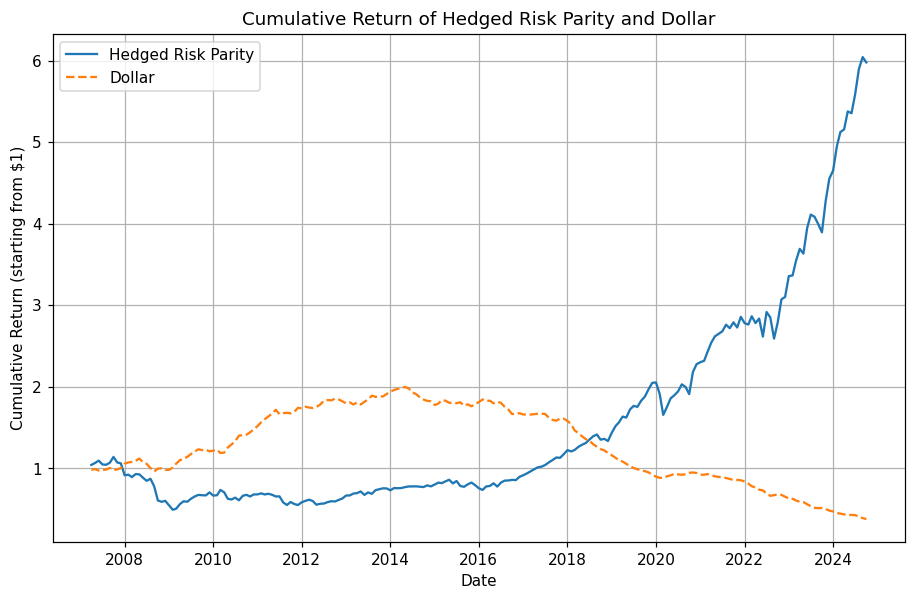

In [163]:
### Plots of dollar cumulative return vs DIV
hedged_risk_parity['date'] = pd.to_datetime(hedged_risk_parity['date'])
dollar['date'] = pd.to_datetime(dollar['date'])

# Plotting the cumulative return of hedged risk parity and dollar
plt.figure(figsize=(10, 6))
plt.plot(hedged_risk_parity.date, (1 + hedged_risk_parity['return']).cumprod().reset_index(drop=True), label='Hedged Risk Parity')
plt.plot(dollar[dollar['date'] >= hedged_risk_parity['date'].min()].date, (1 + dollar[dollar['date'] >= hedged_risk_parity['date'].min()]['return']).cumprod().reset_index(drop=True), label='Dollar', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (starting from $1)')
plt.title('Cumulative Return of Hedged Risk Parity and Dollar')
plt.legend()
plt.grid()
plt.show()

***7.b*** We compute the mean, standard deviation and Sharpe ratio of the strategy:

In [164]:
display(dollar['return'].describe())
sharpe_ratio_dollar = (dollar['return'].mean() / dollar['return'].std()) * np.sqrt(12)
print("Sharpe Ratio of Dollar Strategy:", sharpe_ratio_dollar)

count    271.000000
mean      -0.002571
std        0.022299
min       -0.056648
25%       -0.018220
50%       -0.003419
75%        0.011861
max        0.056758
Name: return, dtype: float64

Sharpe Ratio of Dollar Strategy: -0.39933107389965183


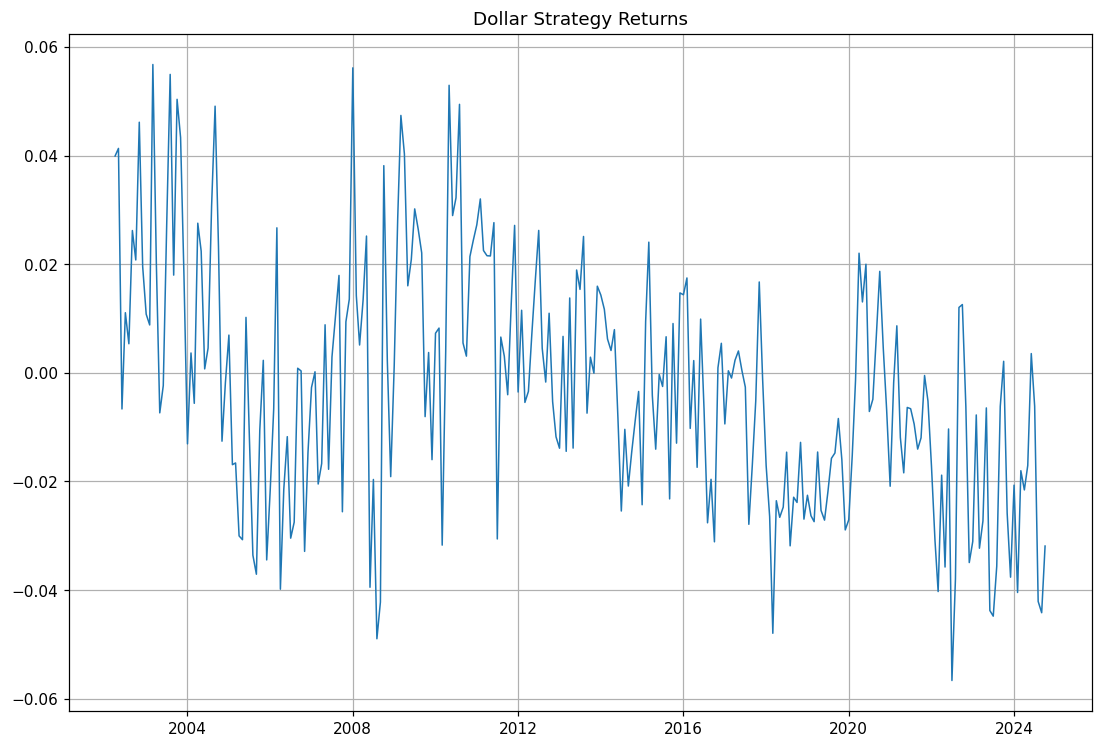

In [165]:
# We plot the returns of the dollar strategy
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(pd.to_datetime(dollar['date']), dollar['return'], linestyle='-', linewidth=1, label='Dollar Returns')
ax.set_title('Dollar Strategy Returns')        
plt.grid()
plt.show()

In [166]:
# we test the hypothesis that the dollar strategy has a mean return of 0
t_stat, p_val = ttest_1samp(dollar['return'], 0)
print('T-statistic: ', t_stat)
print('P-value: ', p_val)
if p_val < 0.05:
    print('Reject the null hypothesis: The average return of Dollar might be different than 0')
else:
    print('Fail to reject the null hypothesis: The average return of Dollar is not statistically significant')

T-statistic:  -1.8976981250030498
P-value:  0.05880250970702852
Fail to reject the null hypothesis: The average return of Dollar is not statistically significant


***7.c*** We regress DOLLAR strategy returns on DIV return

In [167]:
import statsmodels.api as sm
# Prepare data
dollar_series = dollar[['date', 'return']].copy()
div_series = hedged_risk_parity[['date', 'return']].copy().rename(columns={'return': 'DIV_return'})
# Merge and drop missing
regression_df_dollar = pd.merge(dollar_series, div_series, on='date', how='inner').dropna()
# Regression: DOLLAR ~ DIV
X_dollar = sm.add_constant(regression_df_dollar['DIV_return'])  # predictor
y_dollar = regression_df_dollar['return']                 # response
model_dollar = sm.OLS(y_dollar, X_dollar).fit()
print("=== Regression Results: DOLLAR ~ DIV ===")
print(model_dollar.summary())

=== Regression Results: DOLLAR ~ DIV ===
                            OLS Regression Results                            
Dep. Variable:                 return   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     22.61
Date:                Fri, 06 Jun 2025   Prob (F-statistic):           3.69e-06
Time:                        11:43:04   Log-Likelihood:                 526.23
No. Observations:                 211   AIC:                            -1048.
Df Residuals:                     209   BIC:                            -1042.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

# **8. Optimal Fund Portfolio Return (STRAT)**

***8.a***

1. We now assume that you are running a fund that is currently investing in the 1-month T-Bill and the diversified stock-index strategy (DIV). That is, your current (FUND) strategy has return

$
R_{\text{FUND}} = R_{\text{T-Bill}} + a(R_{\text{DIV}} - R_{\text{T-Bill}}) 
$

where \( a \) is chosen so that the annualized volatility of your fund return is 15% (over the past history available).

In [168]:
# We solve a second degree polynomial equation to find a 
import sympy as sp
 
a = sp.Symbol('a')

# Define the coefficients of the polynomial
sigma_tbill = r_f['rate'].std()   # yearly standard deviation of the risk-free rate
sigma_div = hedged_risk_parity['return'].std()*12  # yearly standard deviation of the hedged risk parity returns
# Align the risk-free rate to the hedged_risk_parity dates and compute correlation
# Ensure both date columns are in datetime format
hedged_risk_parity['date'] = pd.to_datetime(hedged_risk_parity['date'])
r_f['date'] = pd.to_datetime(r_f['date'])

# Align and extract the risk-free rate for matching dates
rf_aligned = r_f[r_f['date'].isin(hedged_risk_parity['date'])].reset_index(drop=True)['rate'] / 12
rf_aligned.index = hedged_risk_parity.index  # align index for correlation
rho = hedged_risk_parity['return'].corr(rf_aligned)

target_vol = 0.15      # 15% annualized fund volatility

# Define the polynomial equation
equation = sp.Eq((1-a)**2 * sigma_tbill**2 + 2 * a * (1-a) * rho * sigma_tbill * sigma_div + a**2 * sigma_div**2, target_vol**2)
# Solve the polynomial equation
solutions = sp.solve(equation, a)
solutions

[-0.268766854041602, 0.260400270977508]

In [169]:
# Sanity check 
a1 = solutions[0].evalf()  # First solution
a2 = solutions[1].evalf()  # Second solution
# Calculate the expected volatility of the portfolio
expected_vol_1 = ((1-a1)**2 * sigma_tbill**2 + 2 * a1 * (1 - a1) * rho * sigma_tbill * sigma_div + a1**2 * sigma_div**2) ** 0.5
expected_vol_2 = ((1-a2)**2 * sigma_tbill**2 + 2 * a2 * (1 - a2) * rho * sigma_tbill * sigma_div + a2**2 * sigma_div**2) ** 0.5
print(f"Expected Volatility for a1: {expected_vol_1:.4f}")
print(f"Expected Volatility for a2: {expected_vol_2:.4f}")  

Expected Volatility for a1: 0.1500
Expected Volatility for a2: 0.1500


You are considering adding an *overlay* investment in the dynamic stock index strategies (**MOM**, **REV**) and the currency strategies (**CARRY**, **DOLLAR**) targeting an average annual volatility for your fund of 15%.

Specifically, consider the return to the fund to be

$
R_{\text{FUND}} = R_{\text{T-Bill}} + b \cdot (R_{\text{DIV}} - R_{\text{T-Bill}}) + c \cdot R_{\text{STRAT}},
$

where $ R_{\text{STRAT}} $ is the return to a strategy that combines **MOM**, **REV**, **CARRY**, and **DOLLAR**, and where $ b $ and $ c $ are constants that you will choose so that the average annual volatility remains at

$
\text{Vol}(R_{\text{FUND}}) = 15\%.
$


***8.b*** We use risk-parity based on rolling window estimate of the strategy returns volatilities to combine the four strategies MOM, REV, CARRY and DOLLAR to generate $R_{strat}$

In [170]:
# make all dataframes start from the same date
start_date = max(hedged_risk_parity['date'].min(), momentum['date'].min(), rev_strategy['date'].min(), carry_strategy_df['date'].min(), dollar['date'].min())
hedged_risk_parity_aligned = hedged_risk_parity[hedged_risk_parity['date'] >= start_date].reset_index(drop=True)
momentum_aligned = momentum[momentum['date'] >= start_date].reset_index(drop=True)
rev_strategy_aligned = rev_strategy[rev_strategy['date'] >= start_date].reset_index(drop=True)
carry_strategy_df_aligned = carry_strategy_df[carry_strategy_df['date'] >= start_date].reset_index(drop=True)
dollar_aligned = dollar[dollar['date'] >= start_date].reset_index(drop=True)

In [171]:
# Estimate the volatility of each strategy returns on a rolling window of 60 months
window = 60
vol_dollar = dollar_aligned['return'].rolling(window=window).std()  
vol_momentum = momentum_aligned['momentum_return'].rolling(window=window).std()  
vol_rev_strategy = rev_strategy_aligned['rev_return'].rolling(window=window).std() 
vol_carry = carry_strategy_df_aligned['carry_return'].rolling(window=window).std()

# Create a DataFrame to hold the inverse of volatilities
strategy = pd.DataFrame({
    'date': hedged_risk_parity_aligned['date'],
    'dollar': 1 / vol_dollar,
    'momentum': 1 / vol_momentum,
    'reversal': 1 / vol_rev_strategy,
    'carry': 1 / vol_carry
})
strategy = strategy.dropna().reset_index(drop=True)

# Normalize the inverse volatilities to sum to 1
strategy['total_inverse_vol'] = strategy[['dollar', 'momentum', 'reversal', 'carry']].sum(axis=1)
strategy[['dollar', 'momentum', 'reversal', 'carry']] = strategy[['dollar', 'momentum', 'reversal', 'carry']].div(strategy['total_inverse_vol'], axis=0)
# Drop the total_inverse_vol column as it's no longer needed
strategy = strategy.drop(columns='total_inverse_vol')

# Calculate the weighted returns for each strategy
strategy['weighted_return'] = (
    strategy['dollar'] * dollar_aligned['return'].reset_index(drop=True) +
    strategy['momentum'] * momentum_aligned['momentum_return'].reset_index(drop=True) +
    strategy['reversal'] * rev_strategy_aligned['rev_return'].reset_index(drop=True) +
    strategy['carry'] * carry_strategy_df_aligned['carry_return'].reset_index(drop=True)
)    

strategy

,date,dollar,momentum,reversal,carry,weighted_return
0,2012-03-01,0.342785,0.235590,0.195612,0.226012,0.018405
1,2012-04-01,0.342469,0.236222,0.194064,0.227246,0.016852
2,2012-05-01,0.342374,0.236198,0.193788,0.227640,-0.005879
3,2012-06-01,0.342348,0.234973,0.194170,0.228509,0.014103
4,2012-07-01,0.340166,0.236613,0.195751,0.227470,0.028972
...,...,...,...,...,...,...
147,2024-06-01,0.339437,0.200983,0.205987,0.253593,-0.003584
148,2024-07-01,0.341761,0.199179,0.204516,0.254544,0.000459
149,2024-08-01,0.340020,0.202064,0.206135,0.251780,-0.001180
150,2024-09-01,0.335254,0.204119,0.207784,0.252844,0.000830


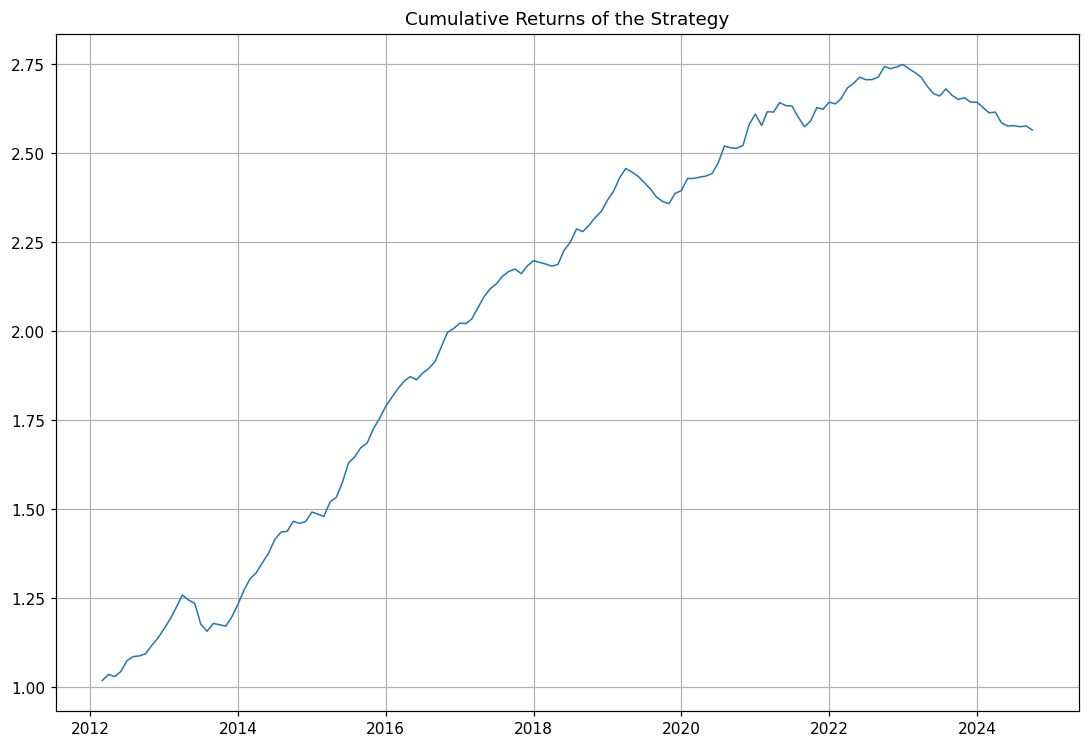

In [172]:
# We plot the cumulative returns of the strategy
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(pd.to_datetime(strategy['date']), (1 + strategy['weighted_return']).cumprod(), linestyle='-', linewidth=1, label='Strategy Returns')
ax.set_title('Cumulative Returns of the Strategy')
plt.grid()
plt.show()

In [173]:
display(strategy['weighted_return'].describe())
sharpe_ratio_strategy = ((strategy['weighted_return']-(r_f[r_f['date'] >= start_date]['rate']/12).reset_index(drop=True)).mean() / strategy['weighted_return'].std()) * np.sqrt(12)
print("Sharpe Ratio of the Strategy:", sharpe_ratio_strategy)

count    152.000000
mean       0.006284
std        0.011780
min       -0.047627
25%       -0.002618
50%        0.006112
75%        0.014589
max        0.034851
Name: weighted_return, dtype: float64

Sharpe Ratio of the Strategy: 1.6647319059824515


***8.c*** We compute constants b and c that make the volatility of $R_{\text{FUND}} = (1 - b) R_{\text{T-Bill}} + b R_{\text{DIV}} + c R_{\text{STRAT}}$ equal to 15\%

In [174]:
# Align strategy, hedged_risk_parity, and r_f dataframes on 'date'
start_date = max(strategy['date'].min(), hedged_risk_parity_aligned['date'].min(), r_f['date'].min())
strategy_aligned = strategy[strategy['date'] >= start_date].reset_index(drop=True)
hedged_risk_parity_aligned = hedged_risk_parity_aligned[hedged_risk_parity_aligned['date'] >= start_date].reset_index(drop=True)
r_f_aligned = r_f[r_f['date'] >= start_date].reset_index(drop=True)    

In [175]:
# compute overall volatility of strategy, hedged_risk_parity, and risk-free rate
vol_strategy = strategy_aligned['weighted_return'].std()*12  # Annualized volatility
r_f_vol = r_f_aligned['rate'].std()  # risk-free rate volatility
vol_hedged_risk_parity = hedged_risk_parity_aligned['return'].std()*12  # Annualized volatility
# Compute the correlation between strategy and hedged risk parity
rho_strategy_hedged = strategy_aligned['weighted_return'].corr(hedged_risk_parity_aligned['return'])
# Compute the correlation between strategy and risk-free rate
rho_strategy_rf = strategy_aligned['weighted_return'].corr(r_f_aligned['rate']/12)
# Compute the correlation between hedged risk parity and risk-free rate
rho_hedged_rf = hedged_risk_parity_aligned['return'].corr(r_f_aligned['rate']/12)


# Write the variance of the fund as a second degree polynomial equation
b = sp.Symbol('b')
c = 1 #set arbitrary value for c to find the value of b
# Define the coefficients of the polynomial 
equation = sp.Eq((1-b)**2 * r_f_vol**2 + b**2 * vol_hedged_risk_parity**2 + c**2*vol_strategy**2 + \
                 2 * b * (1-b) * rho_hedged_rf * r_f_vol * vol_hedged_risk_parity + \
                 2 * b * c * rho_strategy_hedged * vol_hedged_risk_parity * vol_strategy + \
                 2 * (1-b) * c * rho_strategy_rf * r_f_vol * vol_strategy, 0.15**2)  # target volatility of 15% per year
# Solve the polynomial equation
solutions = sp.solve(equation, b)
# Sanity check
solutions

[-0.134490571317461, 0.141149057148430]

In [176]:
# Sanity check
b1 = solutions[0].evalf()  # First solution
b2 = solutions[1].evalf()  # Second solution
# Calculate the expected volatility of the portfolio
expected_vol_1 = ((1-b1)**2 * r_f_vol**2 + b1**2 * vol_hedged_risk_parity**2 + c**2*vol_strategy**2 + \
                  2 * b1 * (1-b1) * rho_hedged_rf * r_f_vol * vol_hedged_risk_parity + \
                  2 * b1 * c * rho_strategy_hedged * vol_hedged_risk_parity * vol_strategy + \
                  2 * (1-b1) * c * rho_strategy_rf * r_f_vol * vol_strategy) ** 0.5
expected_vol_2 = ((1-b2)**2 * r_f_vol**2 + b2**2 * vol_hedged_risk_parity**2 + c**2*vol_strategy**2 + \
                  2 * b2 * (1-b2) * rho_hedged_rf * r_f_vol * vol_hedged_risk_parity + \
                  2 * b2 * c * rho_strategy_hedged * vol_hedged_risk_parity * vol_strategy + \
                  2 * (1-b2) * c * rho_strategy_rf * r_f_vol * vol_strategy) ** 0.5
print(f"Expected Volatility for b1: {expected_vol_1:.4f}")
print(f"Expected Volatility for b2: {expected_vol_2:.4f}")

Expected Volatility for b1: 0.1500
Expected Volatility for b2: 0.1500


***8.d***

In [177]:
# Since we aligned the two portfolios on the same date, we recompute factor a to have a volatility of 15% per year
rho = hedged_risk_parity_aligned['return'].corr(rf_aligned)

target_vol = 0.15      # 15% annualized fund volatility

# Define the polynomial equation
equation = sp.Eq((1-a)**2 * r_f_vol**2 + 2 * a * (1-a) * rho * r_f_vol * vol_hedged_risk_parity + a**2 * vol_hedged_risk_parity**2, target_vol**2)
# Solve the polynomial equation
solutions = sp.solve(equation, a)
a1 = solutions[0].evalf()  # First solution
a2 = solutions[1].evalf()  # Second solution$
solutions

[-0.317017886253451, 0.319436376374122]

In [178]:
# Cumulative return of Fund 1 : (1-a)R_f + aR_DIV

# we choose solutions a2 and b1 
portfolio_1 = pd.DataFrame()
portfolio_1['date'] = strategy_aligned['date'] 
a1_float = float(a2)
portfolio_1['return'] = (1 - a1_float) * (r_f_aligned['rate'] / 12) + a1_float * hedged_risk_parity_aligned['return']
portfolio_1['excess_return'] = portfolio_1['return'] - (r_f_aligned['rate'] / 12)

In [179]:
portfolio_2 = pd.DataFrame()
portfolio_2['date'] = strategy_aligned['date']
b1_float = float(b2)
portfolio_2['return'] = (1 - b1_float) * (r_f_aligned['rate'] / 12) + b1_float * hedged_risk_parity_aligned['return'] + strategy_aligned['weighted_return']  #since c=1
portfolio_2['excess_return'] = portfolio_2['return'] - (r_f_aligned['rate'] / 12)

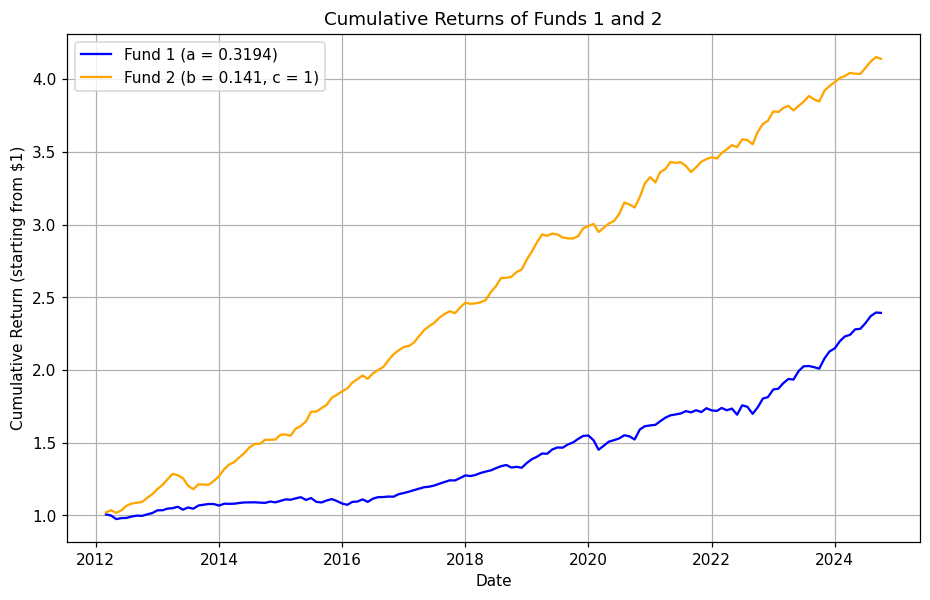

In [180]:
# plort the cumulative returns of the two portfolios
plt.figure(figsize=(10, 6))
portfolio_1['cumulative_return'] = (1 + portfolio_1['return']).cumprod()
portfolio_2['cumulative_return'] = (1 + portfolio_2['return']).cumprod()
plt.plot(portfolio_1['date'], portfolio_1['cumulative_return'], label='Fund 1 (a = 0.3194)', color='blue')
plt.plot(portfolio_2['date'], portfolio_2['cumulative_return'], label='Fund 2 (b = 0.141, c = 1)', color='orange')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (starting from $1)')
plt.title('Cumulative Returns of Funds 1 and 2')
plt.legend()
plt.grid()
plt.show()


In [181]:
# Calculate Sharpe Ratio for the portfolios
sharpe_ratio_portfolio_1 = (portfolio_1['excess_return'].mean() / portfolio_1['excess_return'].std()) * np.sqrt(12)
sharpe_ratio_portfolio_2 = (portfolio_2['excess_return'].mean() / portfolio_2['excess_return'].std()) * np.sqrt(12)
print(f"Sharpe Ratio of Fund 1: {sharpe_ratio_portfolio_1:.4f}")
print(f"Sharpe Ratio of Fund 2: {sharpe_ratio_portfolio_2:.4f}")

Sharpe Ratio of Fund 1: 1.3320
Sharpe Ratio of Fund 2: 2.2655


In [182]:
display((portfolio_1['return']*12).describe())
display((portfolio_2['return']*12).describe())

count    152.000000
mean       0.070050
std        0.152405
min       -0.509345
25%       -0.011591
50%        0.084143
75%        0.159775
max        0.545706
Name: return, dtype: float64

count    152.000000
mean       0.113633
std        0.150021
min       -0.495054
25%        0.009930
50%        0.124255
75%        0.228367
max        0.480706
Name: return, dtype: float64


# **9. Performance and risk analysis for the Fund strategy**

In [183]:

from pathlib import Path
from io import StringIO

csv_path = Path("./data/F-F_Research_Data_5_Factors_2x3.csv") 

txt = csv_path.read_text()


monthly_txt = txt.split("Annual Factors")[0]

lines = monthly_txt.splitlines()
header_i = next(i for i, line in enumerate(lines) if line.startswith(",Mkt-RF"))
csv_block = "\n".join(lines[header_i:]) 


df = pd.read_csv(StringIO(csv_block))


df.rename(columns={df.columns[0]: "yyyymm"}, inplace=True)
df["date"] = pd.to_datetime(df["yyyymm"].astype(str) + "01", format="%Y%m%d")
df.set_index("date", inplace=True)
df.drop(columns=["yyyymm"], inplace=True)


ff5 = df.astype("float64") / 100.0


ff5.sort_index(inplace=True)


ff5.head(), ff5.tail()


(            Mkt-RF     SMB     HML     RMW     CMA      RF
 date                                                      
 1963-07-01 -0.0039 -0.0048 -0.0081  0.0064 -0.0115  0.0027
 1963-08-01  0.0508 -0.0080  0.0170  0.0040 -0.0038  0.0025
 1963-09-01 -0.0157 -0.0043  0.0000 -0.0078  0.0015  0.0027
 1963-10-01  0.0254 -0.0134 -0.0004  0.0279 -0.0225  0.0029
 1963-11-01 -0.0086 -0.0085  0.0173 -0.0043  0.0227  0.0027,
             Mkt-RF     SMB     HML     RMW     CMA      RF
 date                                                      
 2024-12-01 -0.0315 -0.0384 -0.0300  0.0191 -0.0121  0.0037
 2025-01-01  0.0280 -0.0122  0.0162 -0.0233 -0.0324  0.0037
 2025-02-01 -0.0243 -0.0493  0.0491  0.0109  0.0306  0.0033
 2025-03-01 -0.0639 -0.0149  0.0290  0.0211 -0.0047  0.0034
 2025-04-01 -0.0085 -0.0185 -0.0341 -0.0284 -0.0267  0.0035)

In [188]:
import statsmodels.api as sm

start_date = max(ff5.index.min(), strategy['date'].min())
end_date   = min(ff5.index.max(), strategy['date'].max())

strategy_aligned = (
    strategy.loc[(strategy['date'] >= start_date) & (strategy['date'] <= end_date)]
            .set_index('date')
            .sort_index()
)

ff5_aligned = ff5.loc[start_date:end_date]

# ----------------------------------------------------------------------
# 2.  Build the monthly excess return of STRAT
# ----------------------------------------------------------------------
y = strategy_aligned['weighted_return'] - ff5_aligned['RF']   # R_STRAT − r_f


# 3.  Prepare X (five factors) and run OLS with Newey–West SE (lag=1)

X = sm.add_constant(ff5_aligned[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']])
model = sm.OLS(y, X, missing='drop').fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 1}
)

#display results
print(model.summary())

alpha_monthly  = model.params['const']
alpha_annual   = alpha_monthly * 12
alpha_tstat    = model.tvalues['const']      # already HAC-robust

print(f"\nα_STRAT (monthly) : {alpha_monthly: .4%}  (t = {alpha_tstat: .2f})")
print(f"α_STRAT (annual)  : {alpha_annual : .4%}")
print(f"R²                : {model.rsquared: .3f}")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.023
Method:                 Least Squares   F-statistic:                    0.5377
Date:                Fri, 06 Jun 2025   Prob (F-statistic):              0.747
Time:                        11:53:20   Log-Likelihood:                 452.92
No. Observations:                 152   AIC:                            -893.8
Df Residuals:                     146   BIC:                            -875.7
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0052      0.001      4.205      0.0